<h3> <b>Project Based Virtual Intern: Data Scientist ID/X Partners x Rakamin Academy

Author: Arga Bathara

Date: 3 August 2025

<h2> <b>Credit Risk Prediction

### <b>Introduction

Acting as a Data Scientist at ID/X Partners, this project aims to assist a multifinance client in enhancing their credit risk assessment and management. The main objective is to develop a machine learning model capable of predicting credit risk based on a provided dataset of historical loans, which includes both approved and rejected applications. An accurate predictive model will help the client optimize business decisions and minimize potential financial losses.

The model development process will follow these core steps:
* Data Understanding
* Exploratory Data Analysis (EDA)
* Data Preparation
* Data Modeling
* Evaluation

---

### <b>Preparing the Enviroment

Import the required libraries and load the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dataset/loan_data_2007_2014.csv', low_memory=False)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# from google.colab import drive
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# from sklearn.model_selection import GridSearchCV

---

### <b>Data Understanding

In [3]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,...,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,...,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,...,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,...,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN
466284,466284,9199665,11061576,10000,10000,9975.0,36 months,19.20,367.58,D,...,NaN,NaN,NaN,NaN,NaN,NaN,16000.0,NaN,NaN,NaN


Mengecek struktur data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

<b> Insight </b>
- Data memiliki 466285 baris dan 75 kolom
- Jenis data yang dimuat meliputi integer, float, dan object


Mengecek distribusi data

In [ ]:
df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


Memeriksa fitur-fitur yang akan digunakan untuk menentukan credit risk sebagai target

In [ ]:
df['acc_now_delinq'].unique()

array([ 0.,  1., nan,  2.,  3.,  5.,  4.])

In [ ]:
df['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [ ]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [ ]:
df['pub_rec'].unique()

array([ 0.,  1.,  2.,  3.,  4.,  5., nan,  6.,  9.,  8.,  7., 11., 49.,
       10., 54., 12., 18., 19., 16., 15., 14., 40., 63., 13., 21., 34.,
       17.])

<b> Insight </b>
- Fitur-fitur yang akan digunakan untuk menentukan status credit score sebagai target meliputi acc_now_delinq yang menunjukkan jumlah akun dimana peminjam saat ini menunggak, emp_length yang menunjukkan lama kerja peminjam, loan_status yang menunjukkan status pinjaman saat ini, dan pub_rec yang menunjukkan jumlah catatan publik yang merugikan

---

# Exploratory Data Analysis (EDA)

Membuat kolom credit_risk dengan 'bad' sebagai nilai awal kemudian, Menetapkan nilai Good pada data yang memiliki kriteria sebagai berikut:

1. Jumlah akun menunggak (acc_now_delinq) bernilai 0. Nilai ini menunjukkan bahwa peminjam tidak memiliki akun yang saat ini mengalami keterlambatan pembayaran. Peminjam dengan tunggakan aktif memiliki risiko gagal bayar yang lebih tinggi, sehingga hanya peminjam dengan nilai 0 dianggap sebagai kandidat berisiko rendah

2. Masa kerja (emp_length) bernilai lebih dari atau sama dengan 1 tahun. Peminjam dengan lama masa kerja minimal 1 tahun memiliki sumber penghasilan yang lebih stabil, sehingga potensi gagal bayar lebih kecil. Peminjam yang baru bekerja kurang dari 1 tahun dianggap memiliki risiko kredit yang lebih tinggi

3. Status pinjaman (loan_status) berada pada kategori Fully Paid, Current, In Grace Period, atau Does not meet the credit policy. Status:Fully Paid. Status ini menunjukkan bahwa peminjam telah melunasi pinjaman, sedang membayar sesuai jadwal, atau berada dalam masa tenggang yang diizinkan. Kondisi ini mencerminkan kedisiplinan peminjam dan riwayat pembayaran yang baik

4. Tidak ada catatan publik negatif (pub_rec) terkait kredit. Nilai ini menunjukkan bahwa peminjam tidak memiliki masalah hukum atau catatan negatif dalam laporan publik, seperti kebangkrutan atau pelanggaran keuangan lainnya, sehingga lebih layak diberi label risiko rendah

In [ ]:
df['credit_risk'] = 'bad'

good_credit_criteria = (
    (df['acc_now_delinq'] == 0.0) &
    (~df['emp_length'].isin(['< 1 year'])) &
    (df['loan_status'].isin([
        'Fully Paid',
        'Current',
        'In Grace Period',
        'Does not meet the credit policy. Status:Fully Paid'
    ])) &
    (df['pub_rec'] == 0.0)
)

df.loc[good_credit_criteria, 'credit_risk'] = 'good'
df[['acc_now_delinq','emp_length','loan_status', 'pub_rec', 'credit_risk']].sample(15)

,acc_now_delinq,emp_length,loan_status,pub_rec,credit_risk
335759,0.0,< 1 year,Fully Paid,1.0,bad
47612,0.0,9 years,Fully Paid,1.0,bad
143760,0.0,9 years,Current,0.0,good
327070,0.0,4 years,Current,0.0,good
53934,0.0,< 1 year,Current,0.0,bad
208927,0.0,10+ years,Fully Paid,0.0,good
367911,0.0,7 years,Fully Paid,0.0,good
148733,0.0,10+ years,Fully Paid,0.0,good
382969,0.0,10+ years,Current,0.0,good
219935,0.0,5 years,Charged Off,0.0,bad


Memisahkan kolom numerik dan kategori untuk memudahkan analisis data

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])
cat_df = df.select_dtypes(include=['object'])

Melakukan Univariate Analysis pada kolom numerik

In [ ]:
for columns in num_df:
  print('===============================')
  print(f"Value Counts untuk {columns}")
  print(num_df[columns].value_counts())

Value Counts untuk Unnamed: 0
Unnamed: 0
466284    1
0         1
1         1
2         1
3         1
         ..
16        1
17        1
18        1
19        1
20        1
Name: count, Length: 466285, dtype: int64
Value Counts untuk id
id
9199665    1
1077501    1
1077430    1
1077175    1
1076863    1
          ..
1065775    1
1069971    1
1062474    1
1069742    1
1069740    1
Name: count, Length: 466285, dtype: int64
Value Counts untuk member_id
member_id
11061576    1
1296599     1
1314167     1
1313524     1
1277178     1
           ..
1299699     1
1304884     1
1294539     1
1304855     1
1284848     1
Name: count, Length: 466285, dtype: int64
Value Counts untuk loan_amnt
loan_amnt
10000    33023
12000    25519
15000    23486
20000    22759
35000    16596
         ...  
34425        1
33775        1
29525        1
33675        1
33175        1
Name: count, Length: 1352, dtype: int64
Value Counts untuk funded_amnt
funded_amnt
10000    32930
12000    25426
15000    23370
20000   

Mengecek kolom numerik yang memiliki nilai, kosong, dan konstan

In [ ]:
unique_columns_num = []
empty_columns_num = []
constant_columns_num = []

for column in num_df.columns:
    if num_df[column].isna().all():
        empty_columns_num.append(column)
    elif num_df[column].nunique() == num_df.shape[0]:
        unique_columns_num.append(column)
    elif num_df[column].nunique(dropna=True) == 1:
        constant_columns_num.append(column)

print("Kolom dengan semua nilai unik:", unique_columns_num)
print("Kolom yang kosong:", empty_columns_num)
print("Kolom dengan semua nilai sama:", constant_columns_num)

Kolom dengan semua nilai unik: ['Unnamed: 0', 'id', 'member_id']
Kolom yang kosong: ['annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m']
Kolom dengan semua nilai sama: ['policy_code']


<b> Insight </b>
- Kolom Unnamed: 0, id, dan member_id memiliki nilai unik, yang berarti setiap baris pada kolom ini berisi data yang berbeda dan tidak ada nilai yang berulang
- Terdapat beberapa kolom kosong, yaitu annual_inc_joint, dti_joint, verification_status_joint, open_acc_6m, open_il_6m, open_il_12m, open_il_24m, mths_since_rcnt_il, total_bal_il, il_util, open_rv_12m, open_rv_24m, max_bal_bc, all_util, inq_fi, total_cu_tl, dan inq_last_12m, yang tidak memiliki data sama sekali (hanya berisi nilai kosong/NaN)
- Kolom 'policy_code' merupakan satu-satunya kolom dengan nilai konstan, dimana semua baris memiliki nilai yang sama

Menghilangkan kolom unik, kosong, dan konstan dari variabel num_df karena tidak cocok untuk divisualisasikan dalam bentuk histogram

In [ ]:
columns_to_drop = unique_columns_num + empty_columns_num + constant_columns_num
selected_num_df = num_df.drop(columns=columns_to_drop, errors='ignore')

Visualisasi histogram kolom numerik yang telah diseleksi

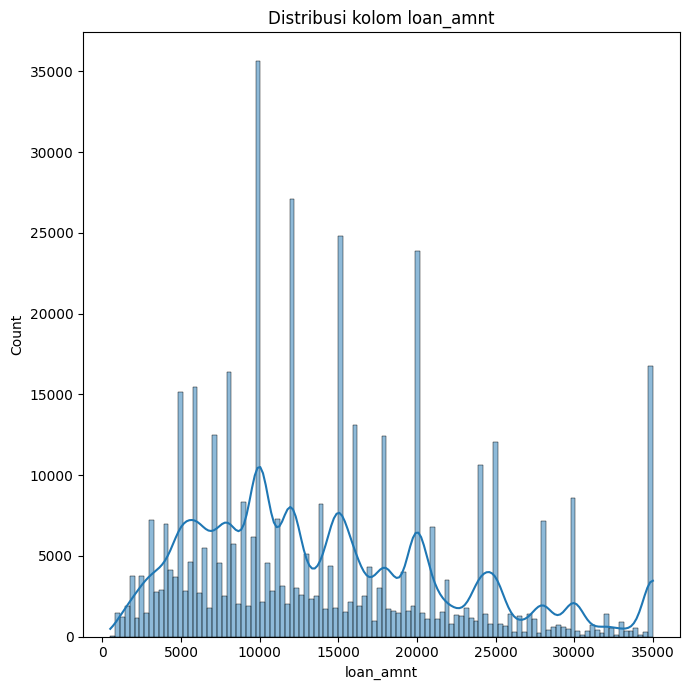

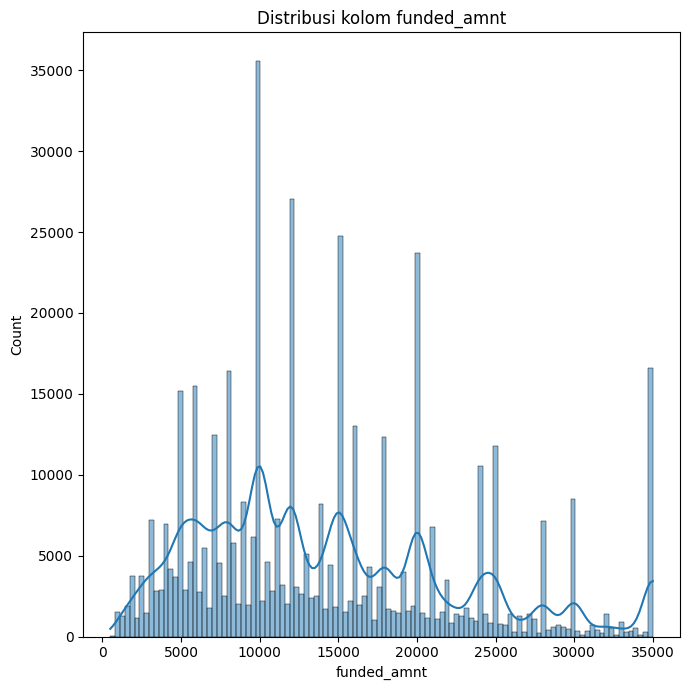

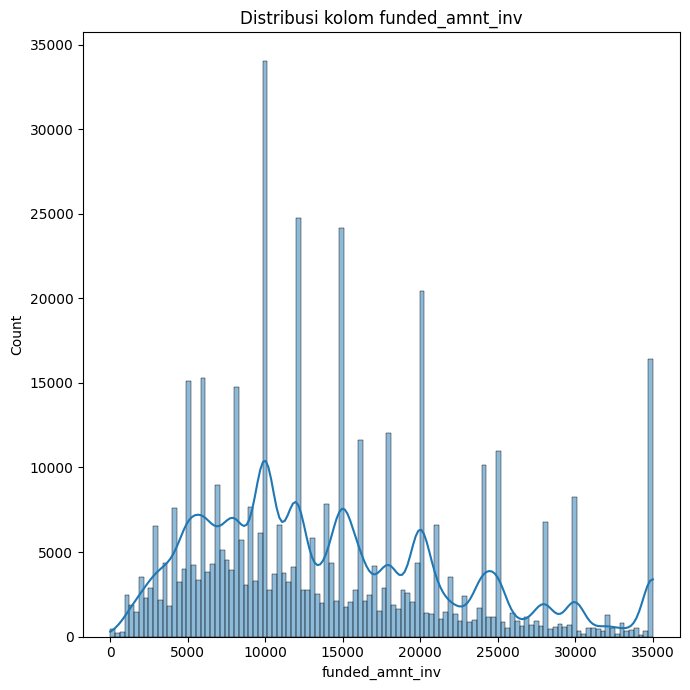

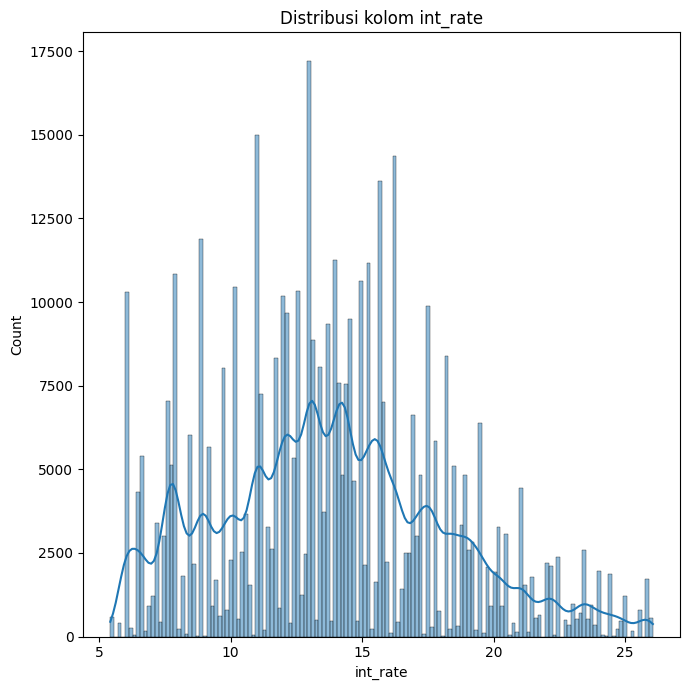

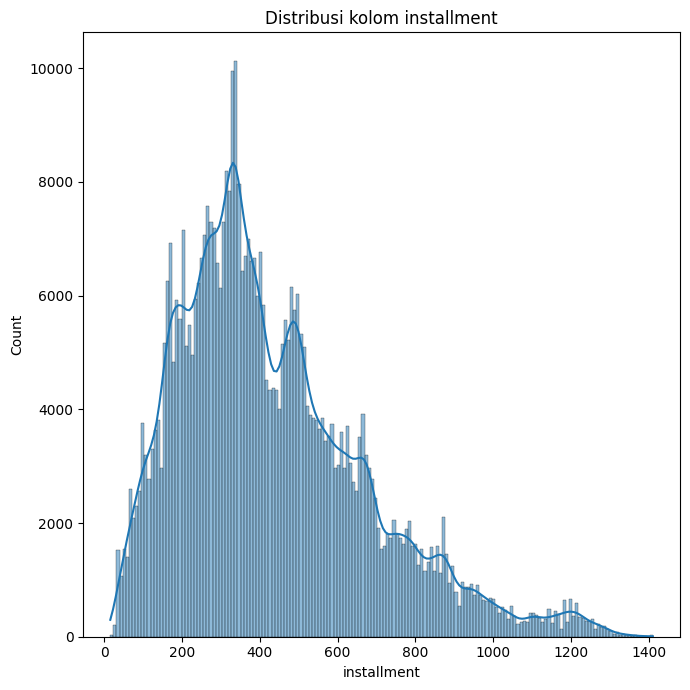

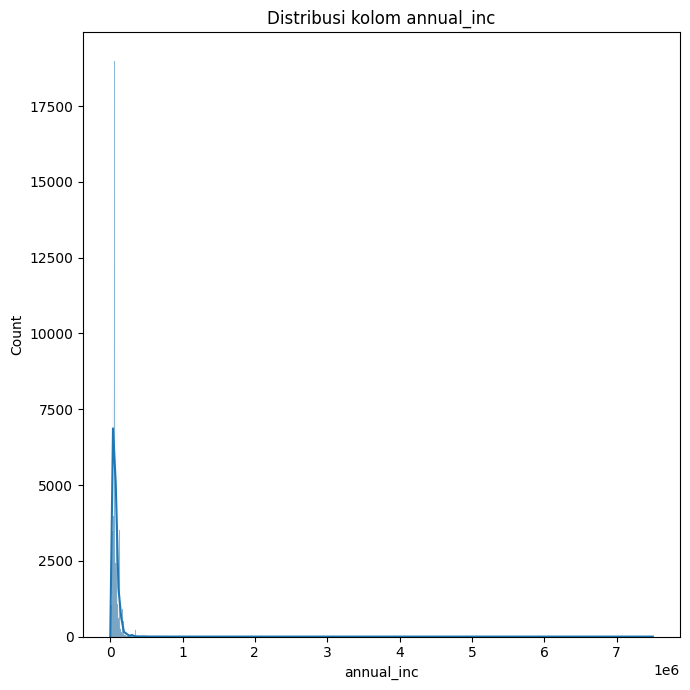

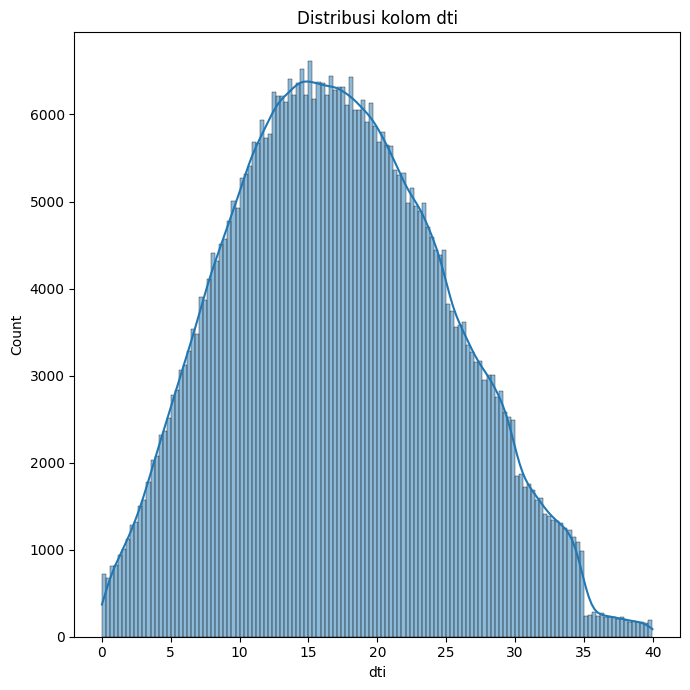

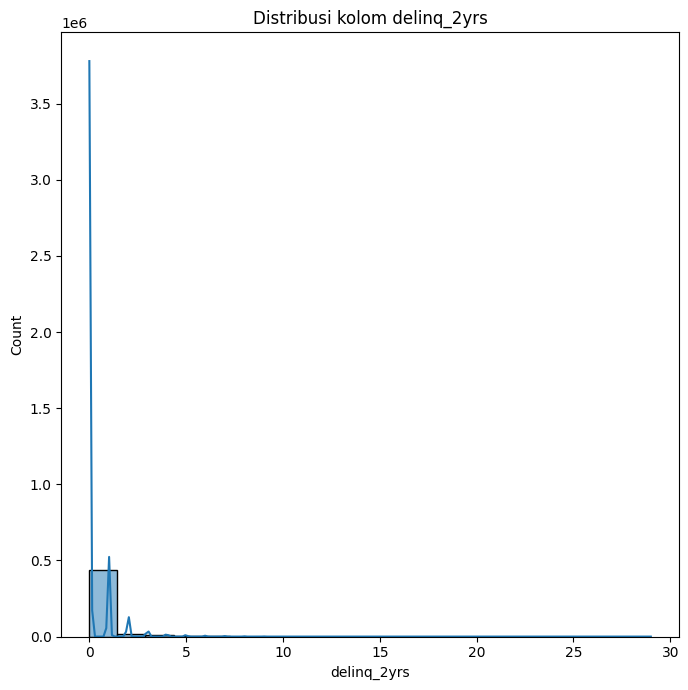

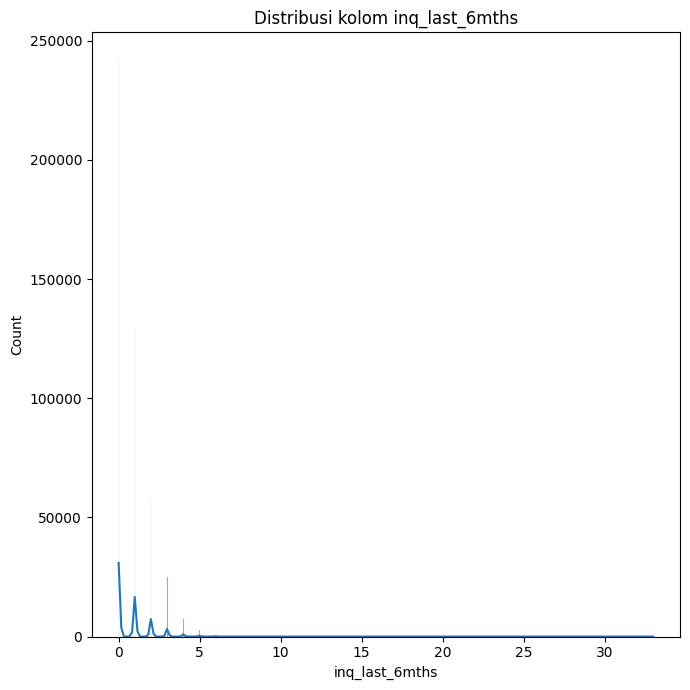

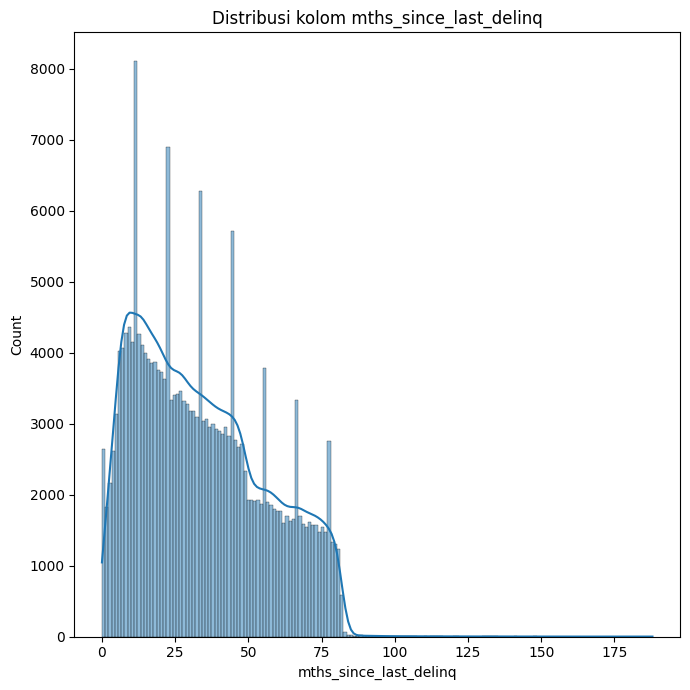

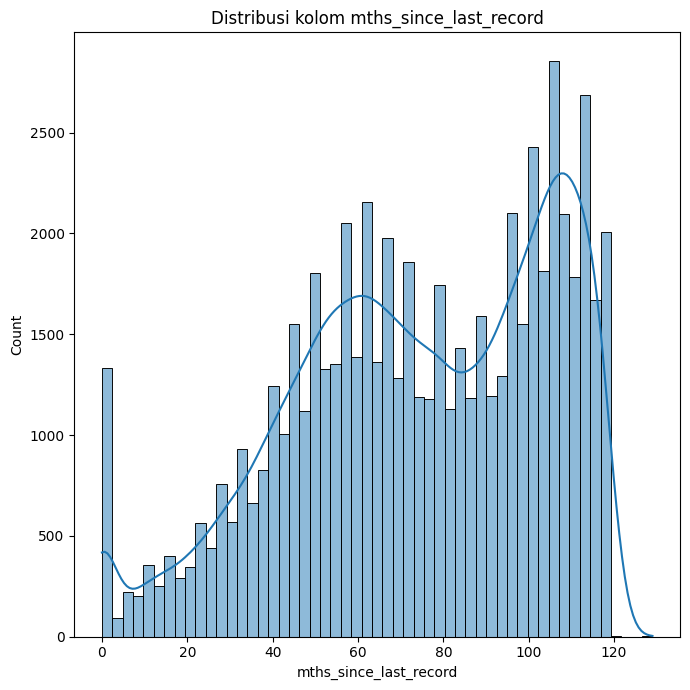

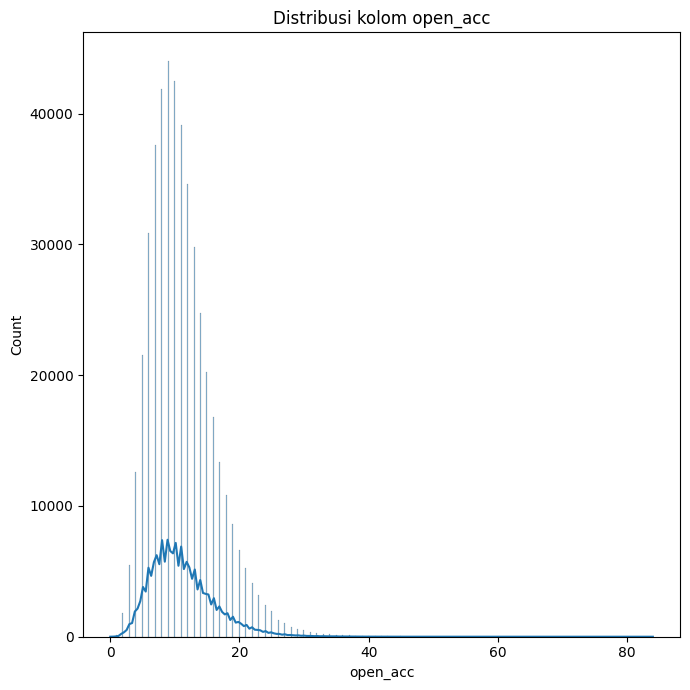

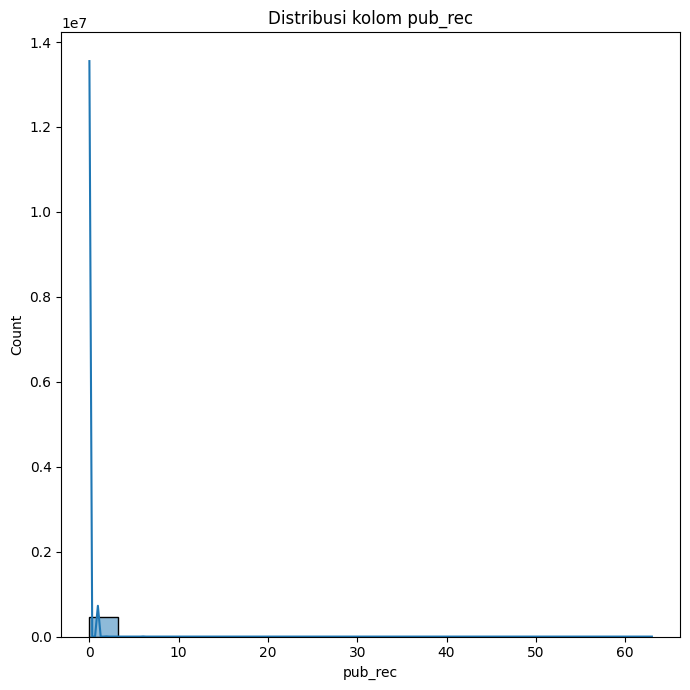

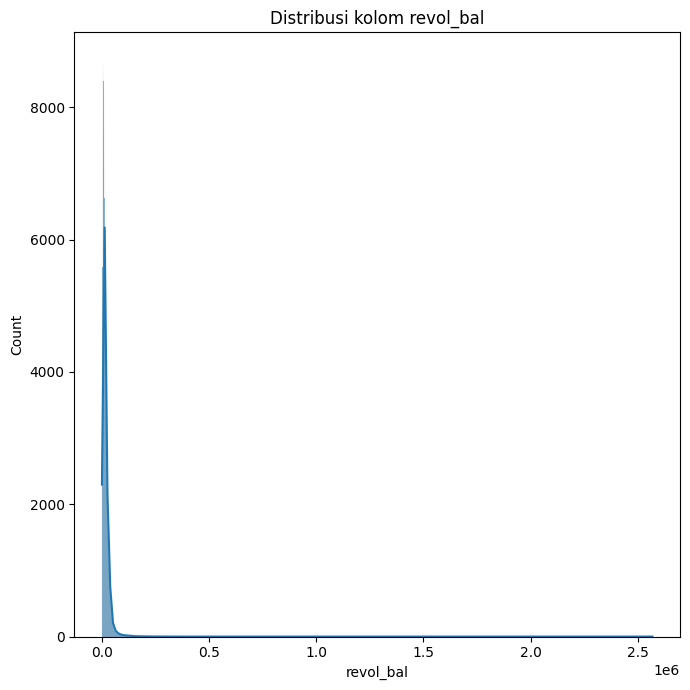

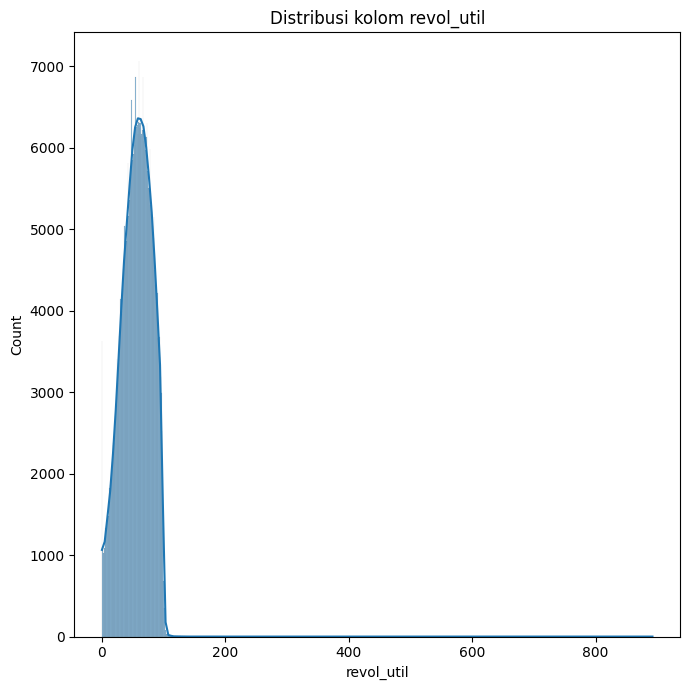

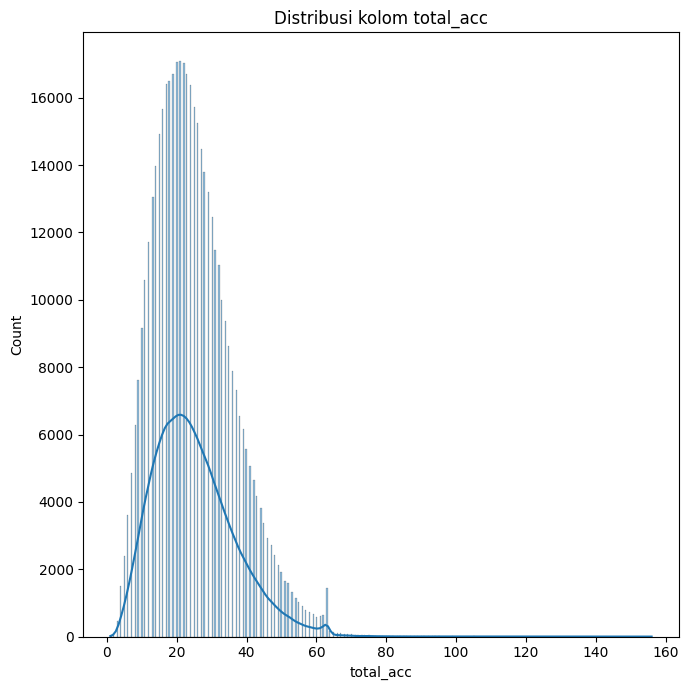

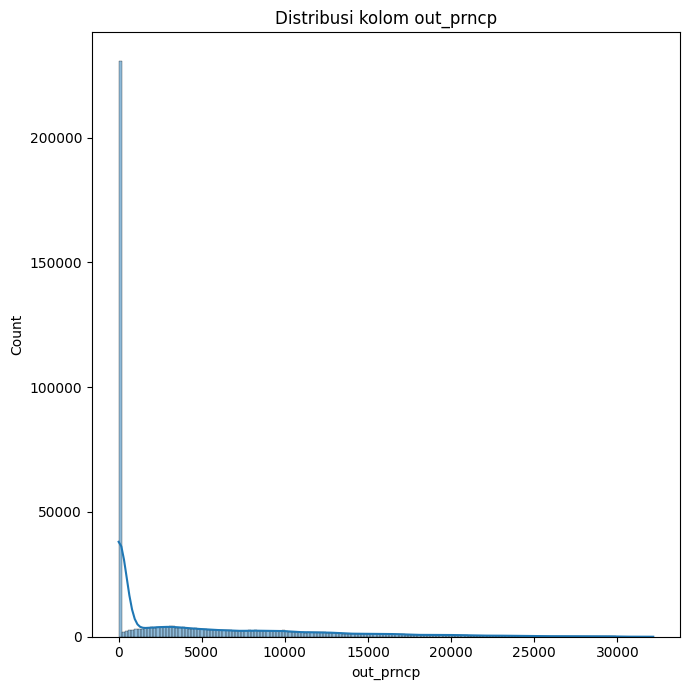

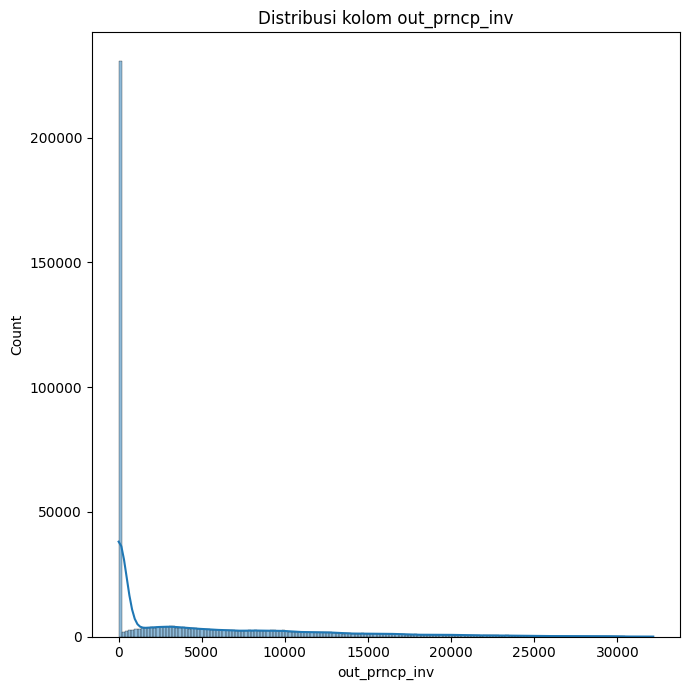

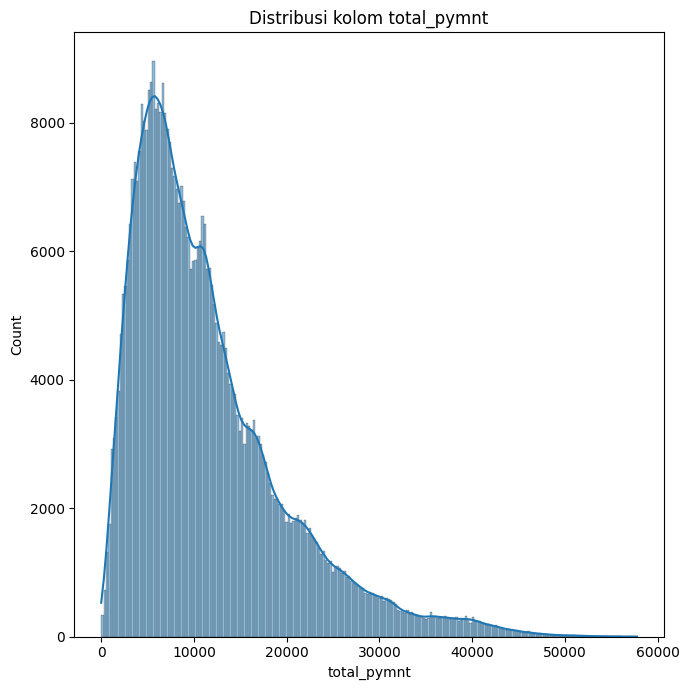

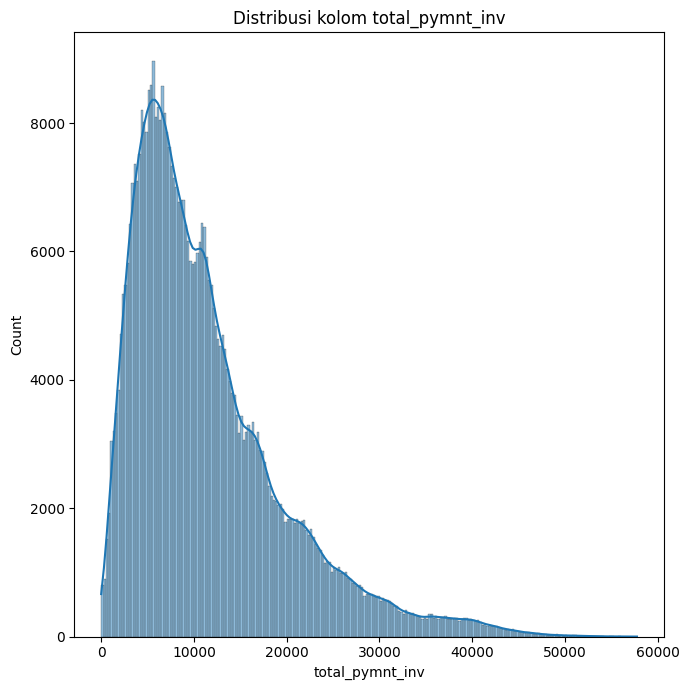

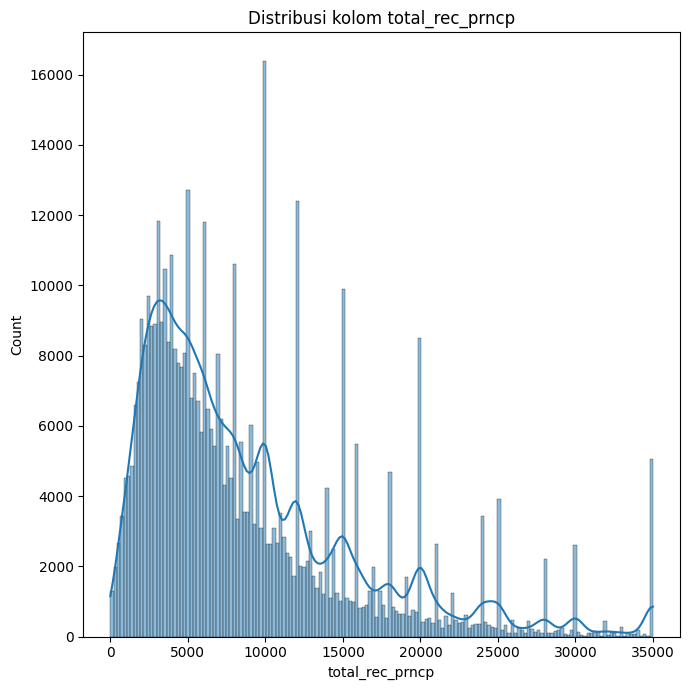

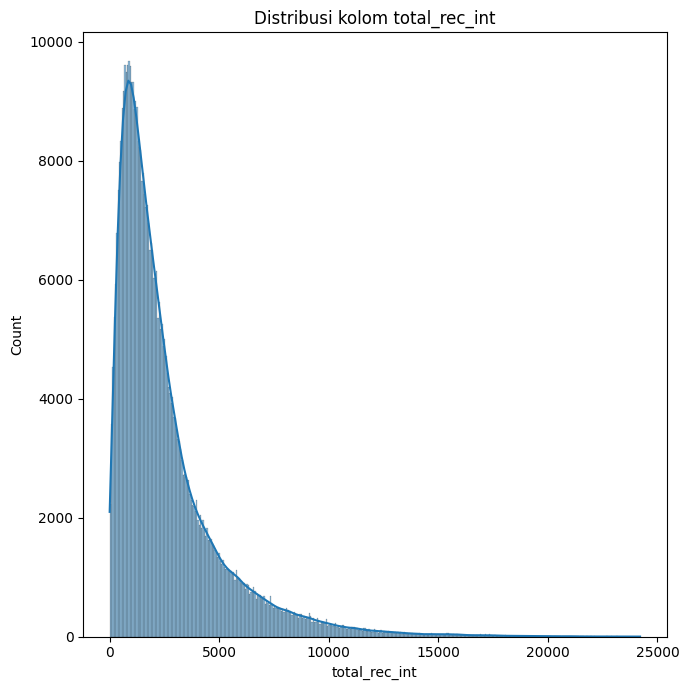

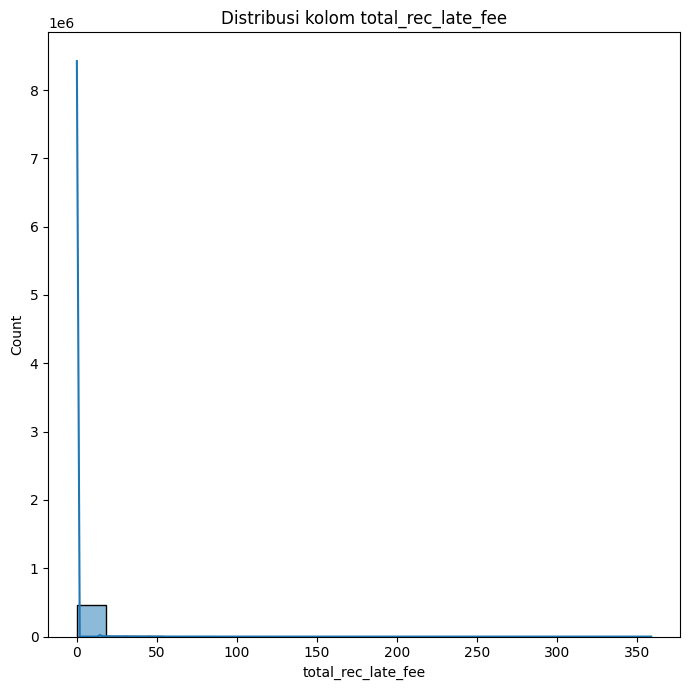

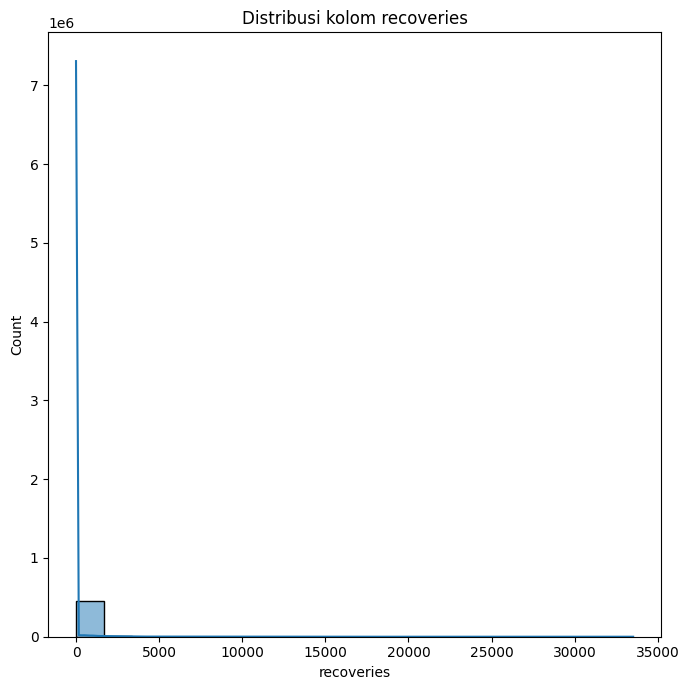

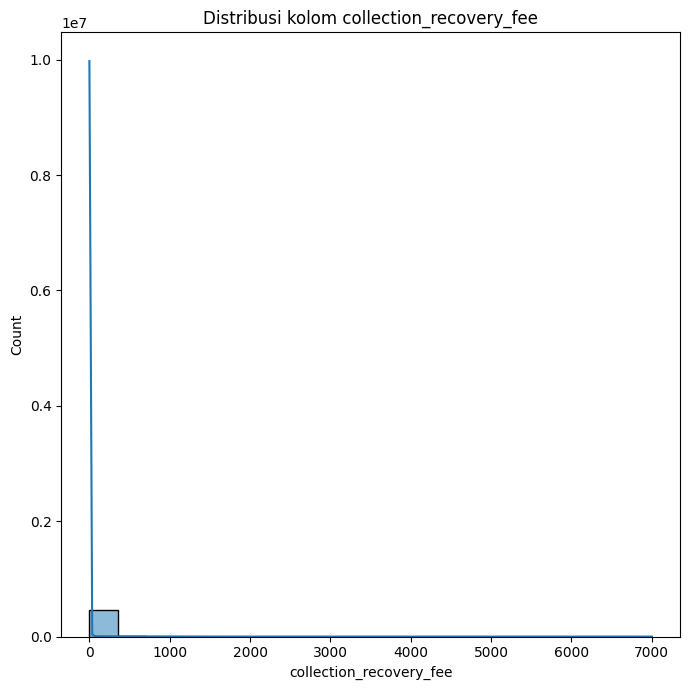

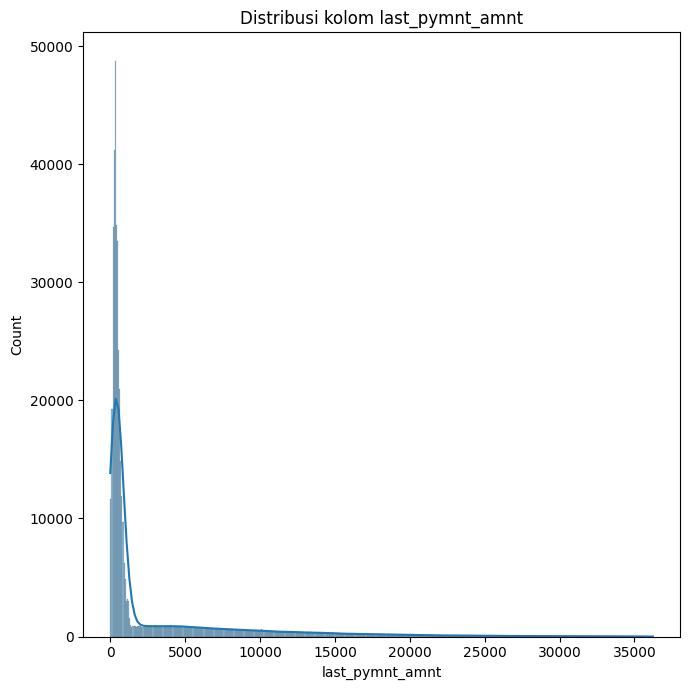

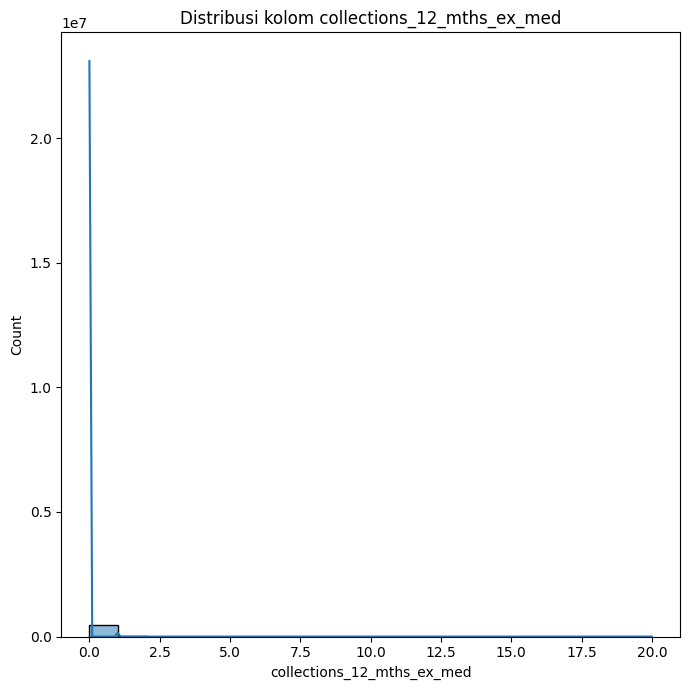

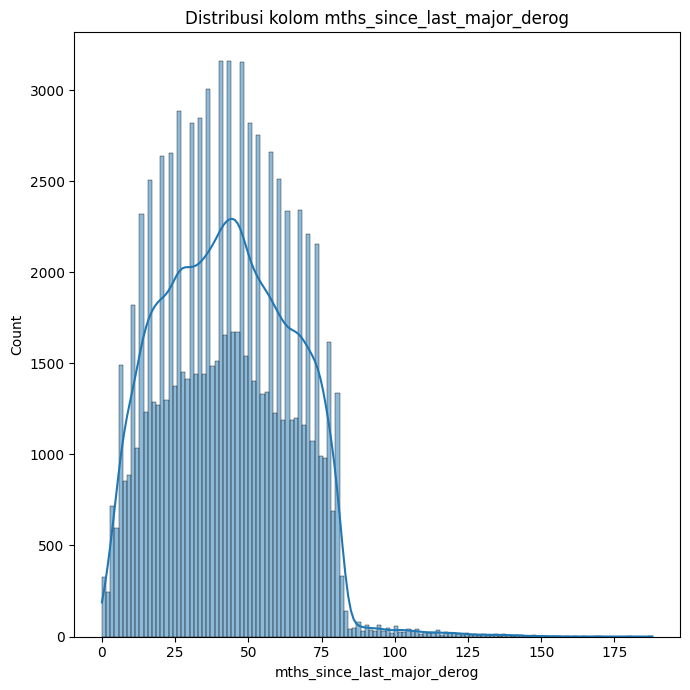

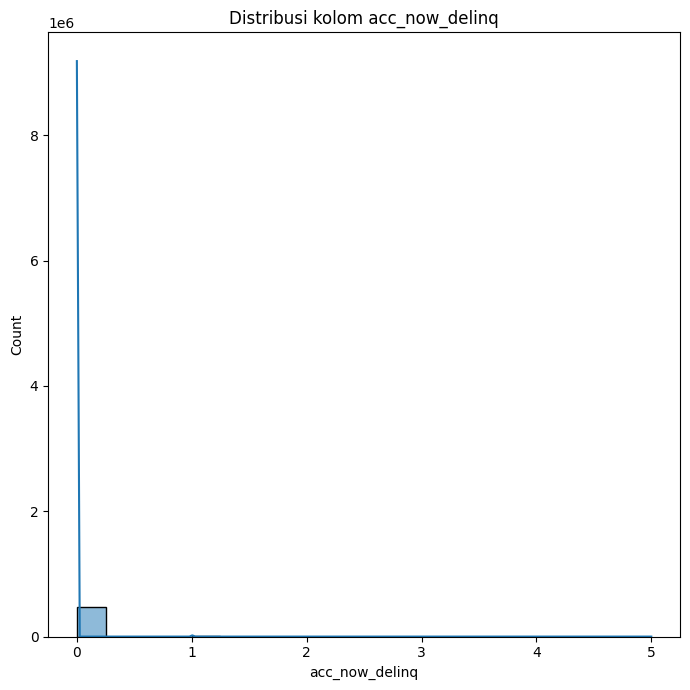

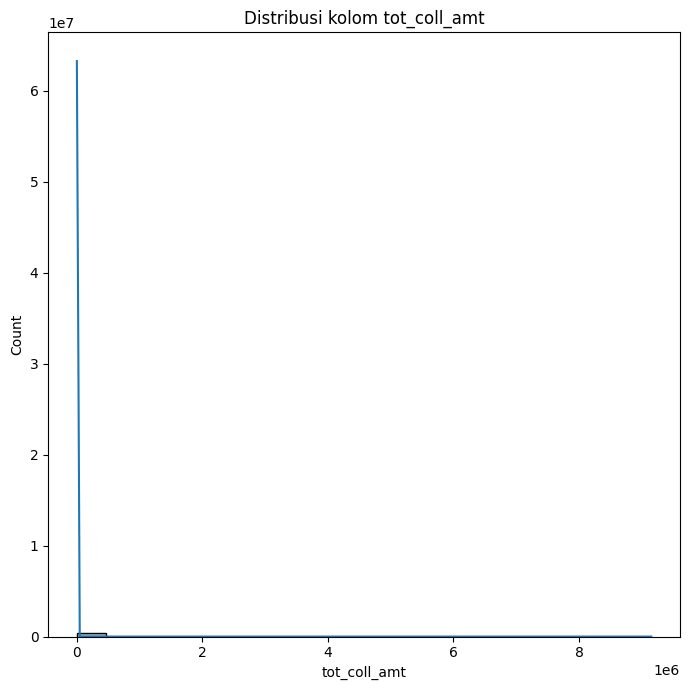

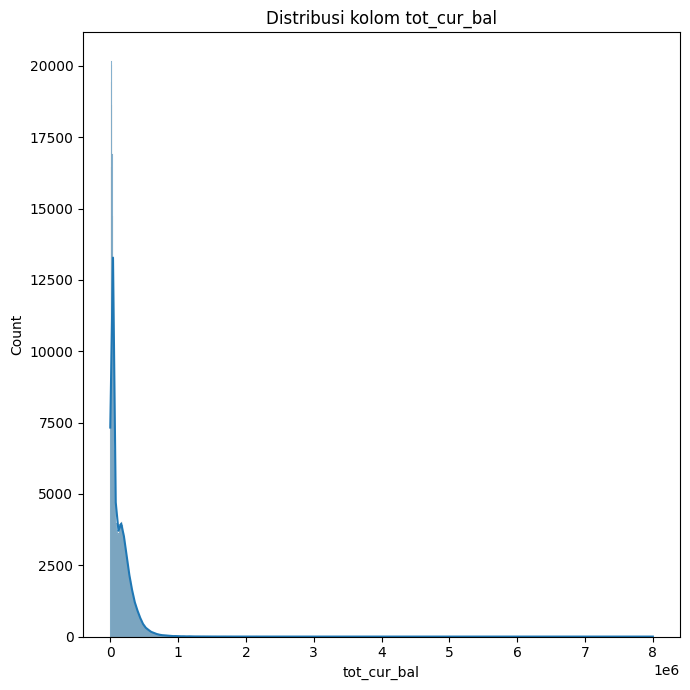

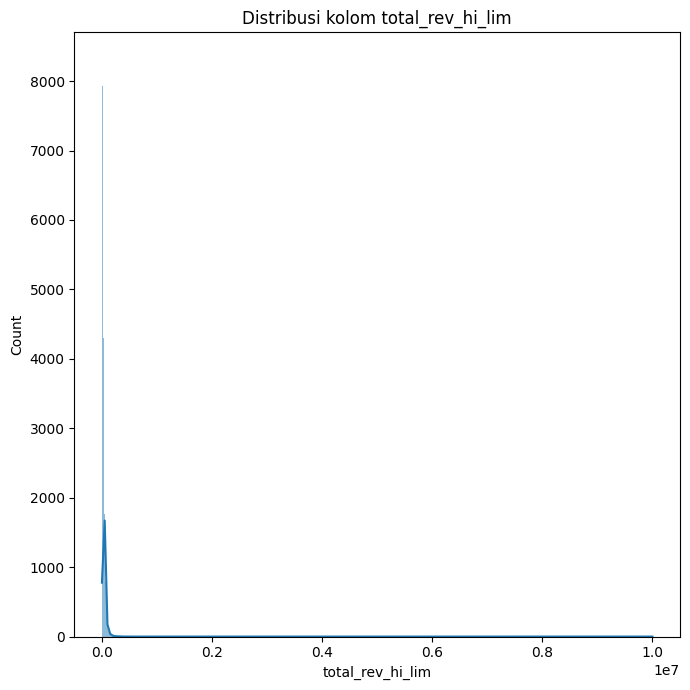

In [ ]:
for columns in selected_num_df:
  plt.figure(figsize=(7,7))
  sns.histplot(data=selected_num_df, x=columns, kde=True)
  plt.title(f'Distribusi kolom {columns}')
  plt.tight_layout()
  plt.show()

<b> Insight </b>
- Sebagian besar fitur memiliki distribusi yang tidak merata (skewed), dengan mayoritas nilai terkonsentrasi di rentang bawah (dekat nol) dan hanya sedikit nilai yang jauh lebih tinggi
- Beberapa kolom menunjukkan distribusi mendekati normal, di mana nilai tersebar relatif merata di sekitar rata-rata
- Terdapat kolom dengan frekuensi data sangat rendah pada beberapa nilai, yang mengindikasikan bahwa data tersebut jarang terjadi atau bersifat kategori namun dikodekan sebagai angka

Melakukan Univariate Analysis pada kolom kategori

In [ ]:
for columns in cat_df:
  print('===============================')
  print(f"Value Counts untuk {columns}")
  print(cat_df[columns].value_counts())

Value Counts untuk term
term
36 months    337953
60 months    128332
Name: count, dtype: int64
Value Counts untuk grade
grade
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: count, dtype: int64
Value Counts untuk sub_grade
sub_grade
B3    31686
B4    30505
C1    26953
C2    26740
B2    26610
C3    25317
B5    25252
C4    24105
B1    22876
C5    22178
A5    21757
D1    19261
A4    19045
D2    17046
D3    14916
D4    14099
A3    12568
D5    11566
A2    10956
A1    10541
E1     9033
E2     8669
E3     6976
E4     5992
E5     5087
F1     3940
F2     3001
F3     2708
F4     2067
F5     1513
G1     1109
G2      823
G3      583
G4      422
G5      385
Name: count, dtype: int64
Value Counts untuk emp_title
emp_title
Teacher                        5399
Manager                        4438
Registered Nurse               2316
RN                             2204
Supervisor                     1967
                               ... 
Kuehls Midwest Distribut

In [ ]:
unique_columns_cat = []
empty_columns_cat = []
constant_columns_cat = []

for column in cat_df.columns:
    if cat_df[column].isna().all():
        empty_columns_cat.append(column)
    elif cat_df[column].nunique() == cat_df.shape[0]:
        unique_columns_cat.append(column)
    elif cat_df[column].nunique(dropna=True) == 1:
        constant_columns_cat.append(column)

print("Kolom dengan semua nilai unik:", unique_columns_cat)
print("Kolom yang kosong:", empty_columns_cat)
print("Kolom dengan semua nilai sama:", constant_columns_cat)

Kolom dengan semua nilai unik: ['url']
Kolom yang kosong: []
Kolom dengan semua nilai sama: ['application_type']


<b> Insight </b>
- Kolom 'url' memiliki nilai unik, yang berarti setiap baris pada kolom ini berisi data yang berbeda dan tidak ada nilai yang berulang
- Tidak terdapat kolom kosong
- Kolom 'application_type' merupakan kolom dengan nilai konstan, dimana semua baris memiliki nilai yang sama

Memeriksa distribusi data pada kolom credit_risk

In [ ]:
print(df['credit_risk'].value_counts())

credit_risk
good    329413
bad     136872
Name: count, dtype: int64


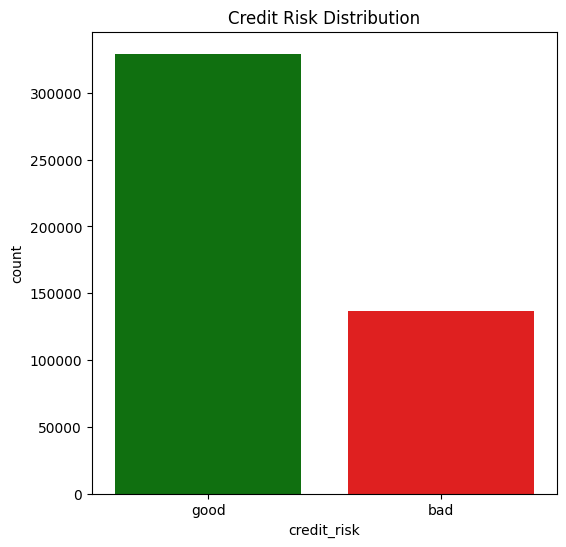

In [ ]:
plt.figure(figsize=(6,6))
colors = ['green', 'red']
sns.countplot(data=df, x='credit_risk', hue='credit_risk', palette=colors, legend=False)
plt.title('Credit Risk Distribution')
plt.show()

Memeriksa distribusi data pada kolom loan_status

In [ ]:
print(df['loan_status'].value_counts())

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


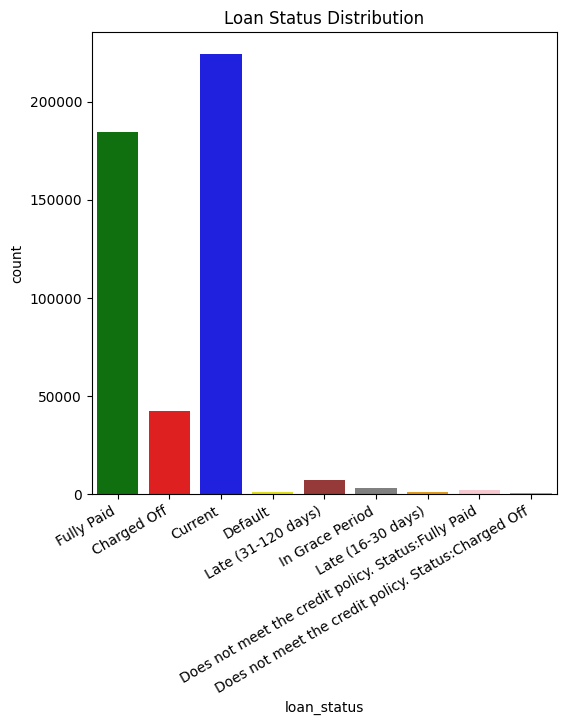

In [ ]:
plt.figure(figsize=(6,6))
colors = ['green', 'red', 'blue', 'yellow', 'brown', 'gray', 'orange', 'pink', 'cyan']
sns.countplot(data=df, x='loan_status', hue='loan_status', palette=colors, legend=False)
plt.xticks(rotation=30, ha='right')
plt.title('Loan Status Distribution')
plt.show()

Memeriksa distribusi data pada kolom grade

In [ ]:
print(df['grade'].value_counts())

grade
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: count, dtype: int64


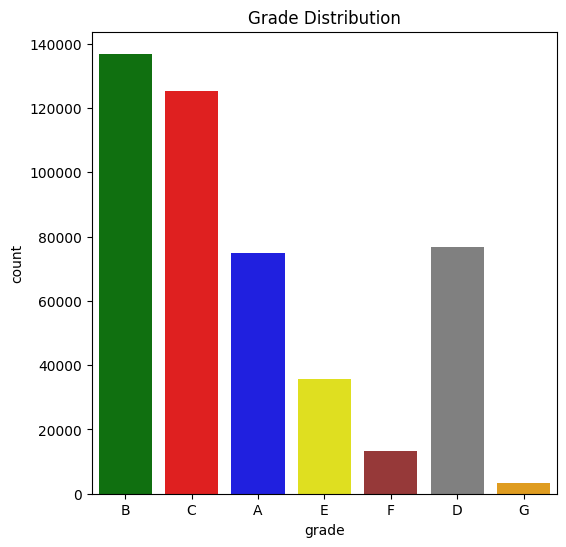

In [ ]:
plt.figure(figsize=(6,6))
colors = ['green', 'red', 'blue', 'yellow', 'brown', 'gray', 'orange']
sns.countplot(data=df, x='grade', hue='grade', palette=colors, legend=False)
plt.title('Grade Distribution')
plt.show()

<b> Insight </b>
- Terdapat 329.413 peminjam dengan status Good, yang berarti sebagian besar peminjam dalam dataset memenuhi kriteria risiko rendah sedangkan, terdapat 136.872 peminjam dengan status Bad, menunjukkan bahwa masih ada persentase signifikan peminjam yang berpotensi berisiko tinggi
- Sebagian besar pinjaman berada dalam status aktif (Current) atau sudah lunas (Fully Paid), yang menunjukkan bahwa mayoritas peminjam mampu memenuhi kewajiban pembayaran tepat waktu atau telah menyelesaikan pinjaman mereka sepenuhnya
- Grade B, C, dan D merupakan tingkatan pinjaman yang paling sering diberikan kepada peminjam. Hal ini mengindikasikan bahwa sebagian besar peminjam dalam dataset memiliki profil risiko sedang

Melakukan Bivariate Analysis credit risk dengan loan status

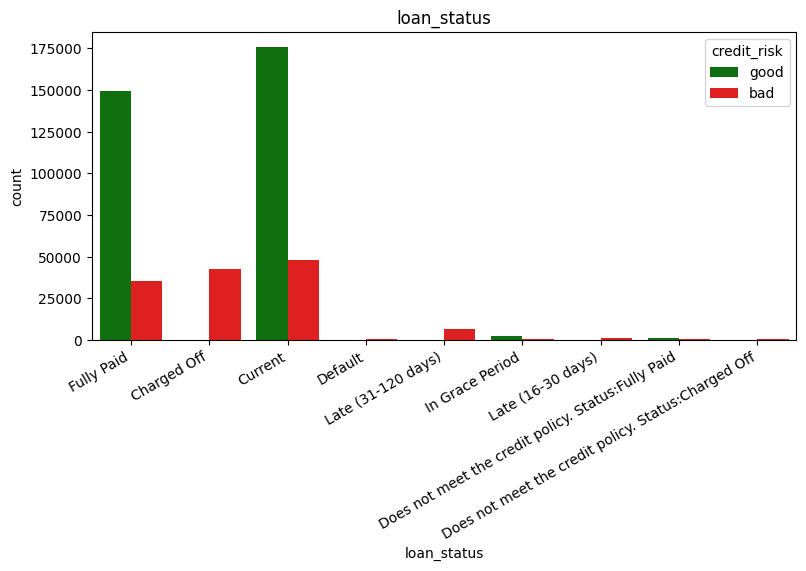

In [ ]:
colors = ['green', 'red']

plt.figure(figsize=(20, 4))
plt.subplot(121)
sns.countplot(x=cat_df['loan_status'], hue=df["credit_risk"], palette=colors)
plt.xticks(rotation=30, ha='right')
plt.title('loan_status')
plt.show()

Melakukan Bivariate Analysis credit risk dengan grade

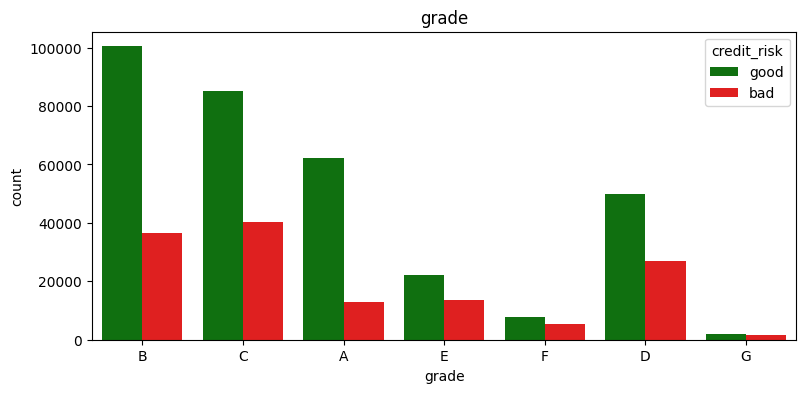

In [ ]:
colors = ['green', 'red']

plt.figure(figsize=(20, 4))
plt.subplot(121)
sns.countplot(x=cat_df['grade'], hue=df["credit_risk"], palette=colors)
plt.title('grade')
plt.show()

Melakukan Bivariate Analysis credit risk dengan purpose

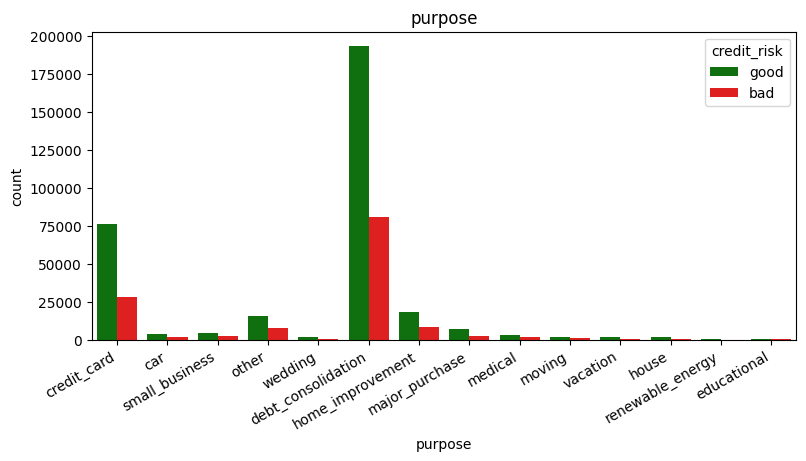

In [ ]:
colors = ['green', 'red']

plt.figure(figsize=(20, 4))
plt.subplot(121)
sns.countplot(x=cat_df['purpose'], hue=df["credit_risk"], palette=colors)
plt.xticks(rotation=30, ha='right')
plt.title('purpose')
plt.show()

<b> Insight </b>
- Mayoritas peminjam dengan status sedang berjalan (Current) atau sudah melunasi pinjaman (Fully Paid) dikategorikan memiliki credit risk “good”, yang menunjukkan riwayat pembayaran yang baik. Namun, terdapat pula sejumlah peminjam dengan status sedang berjalan (Current) yang memiliki credit risk “bad”, menjadikannya kelompok dengan jumlah risiko kredit buruk tertinggi dibanding status pinjaman lainnya. Setelah status Current, kategori dengan credit risk “bad” terbanyak adalah Charged Off, yang menunjukkan peminjam gagal melunasi kewajibannya sepenuhnya
- Semakin rendah grade (D–G), semakin tinggi proporsi pinjaman berisiko "bad", sedangkan grade A–C didominasi kredit berkualitas baik "good", mencerminkan korelasi negatif antara grade dan risiko gagal bayar
- Pinjaman untuk debt consolidation dan credit card adalah yang paling banyak diajukan, dengan keduanya juga memiliki jumlah risiko kredit buruk "bad" tertinggi; sebaliknya, keperluan seperti vacation, wedding, dan renewable energy jauh lebih sedikit volumenya dan relatif lebih sedikit kasus gagal bayar "good".

Memeriksa missing value pada setiap kolom data

In [ ]:
for columns in df:
  missingValue = df[columns].isnull().sum()
  print(f"Missing value pada kolom {columns}: {missingValue}")

Missing value pada kolom Unnamed: 0: 0
Missing value pada kolom id: 0
Missing value pada kolom member_id: 0
Missing value pada kolom loan_amnt: 0
Missing value pada kolom funded_amnt: 0
Missing value pada kolom funded_amnt_inv: 0
Missing value pada kolom term: 0
Missing value pada kolom int_rate: 0
Missing value pada kolom installment: 0
Missing value pada kolom grade: 0
Missing value pada kolom sub_grade: 0
Missing value pada kolom emp_title: 27588
Missing value pada kolom emp_length: 21008
Missing value pada kolom home_ownership: 0
Missing value pada kolom annual_inc: 4
Missing value pada kolom verification_status: 0
Missing value pada kolom issue_d: 0
Missing value pada kolom loan_status: 0
Missing value pada kolom pymnt_plan: 0
Missing value pada kolom url: 0
Missing value pada kolom desc: 340304
Missing value pada kolom purpose: 0
Missing value pada kolom title: 21
Missing value pada kolom zip_code: 0
Missing value pada kolom addr_state: 0
Missing value pada kolom dti: 0
Missing v

Memeriksa persentase missing value yang dimiliki oleh suatu kolom

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = missing_percentage.reset_index()
missing_df.columns = ['Kolom', 'Persentase Missing Value']
missing_df = missing_df[missing_df['Persentase Missing Value'] > 0]

print(missing_df)

                          Kolom  Persentase Missing Value
11                    emp_title                  5.916553
12                   emp_length                  4.505399
14                   annual_inc                  0.000858
20                         desc                 72.981975
22                        title                  0.004504
26                  delinq_2yrs                  0.006219
27             earliest_cr_line                  0.006219
28               inq_last_6mths                  0.006219
29       mths_since_last_delinq                 53.690554
30       mths_since_last_record                 86.566585
31                     open_acc                  0.006219
32                      pub_rec                  0.006219
34                   revol_util                  0.072917
35                    total_acc                  0.006219
46                 last_pymnt_d                  0.080637
48                 next_pymnt_d                 48.728567
49           l

<b> Insight </b>
- Sebagian besar kolom memiliki missing value rendah
- Beberapa kolom memiliki missing value sangat tinggi, bahkan mencapai 100%


# Data Preparation

Menangani missing value dengan menghapus kolom yang memiliki persentase missing value lebih dari 50%

In [ ]:
columns_to_drop = missing_percentage[missing_percentage > 50].index
cleaned_df = df.drop(columns=columns_to_drop)

print("Jumlah kolom setelah penghapusan:", cleaned_df.shape[1])

Jumlah kolom setelah penghapusan: 55


Menangani missing value dengan mengisinya menggunkan median

In [ ]:
for column in cleaned_df.columns:
    if cleaned_df[column].isnull().sum() > 0:
        try:
            median_value = cleaned_df[column].median()
        except:
            cleaned_df[column] = cleaned_df[column].astype('category').cat.codes.replace(-1, None)
            median_value = cleaned_df[column].median()

        cleaned_df[column].fillna(median_value, inplace=True)
        print(f"Kolom '{column}' diisi dengan median: {median_value}")

cleaned_df.info()

/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_df[column].fillna(median_value, inplace=True)
/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_df[column].fillna(median_value, inplace=True)


Kolom 'emp_title' diisi dengan median: 109392.0


/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_df[column].fillna(median_value, inplace=True)
/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_df[column].fillna(median_value, inplace=True)


Kolom 'emp_length' diisi dengan median: 3.0
Kolom 'annual_inc' diisi dengan median: 63000.0


/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_df[column].fillna(median_value, inplace=True)
/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_df[column].fillna(median_value, inplace=True)


...

Kolom 'last_pymnt_d' diisi dengan median: 41.0


/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_df[column].fillna(median_value, inplace=True)
/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_df[column].fillna(median_value, inplace=True)


Kolom 'next_pymnt_d' diisi dengan median: 33.0


/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_df[column].fillna(median_value, inplace=True)
/tmp/ipykernel_1929/3184871053.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_df[column].fillna(median_value, inplace=True)


Kolom 'last_credit_pull_d' diisi dengan median: 41.0
Kolom 'collections_12_mths_ex_med' diisi dengan median: 0.0
Kolom 'acc_now_delinq' diisi dengan median: 0.0
Kolom 'tot_coll_amt' diisi dengan median: 0.0
Kolom 'tot_cur_bal' diisi dengan median: 81539.0
Kolom 'total_rev_hi_lim' diisi dengan median: 22800.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  466285 non-null  int64  
 1   id                          466285 non-null  int64  
 2   member_id                   466285 non-null  int64  
 3   loan_amnt                   466285 non-null  int64  
 4   funded_amnt                 466285 non-null  int64  
 5   funded_amnt_inv             466285 non-null  float64
 6   term                        466285 non-null  object 
 7   int_rate                    466285 non-null  float64

<b> Insight </b>
- Sudah tidak terdapat missing value setelah dilakukan penangan

Mengecek data duplikat

In [ ]:
print('Jumlah data duplikat: ', cleaned_df.duplicated().sum())

Jumlah data duplikat:  0


<b> Insight </b>
- Tidak ditemukan adanya duplikasi data

Menghapus kolom yang memuat data hanya untuk pengenalan seperti id, data yang hanya memiliki satu nilai unik, dan data yang tidak diperlukan

In [ ]:
columns_to_drop = ['Unnamed: 0', 'id', 'member_id', 'application_type', 'url','zip_code']
dcleaned_df = cleaned_df.drop(columns=columns_to_drop, errors='ignore')

Memisah data numerik dan kategori untuk memudahkan proses persiapan data

In [ ]:
dnum_df = dcleaned_df.select_dtypes(include=['int64', 'float64'])
dcat_df = dcleaned_df.select_dtypes(include=['object'])

Memeriksa outlier dengan IQR Method dan visualisasi boxplot

In [ ]:
for column in dnum_df:
    q25 = np.percentile(dnum_df[column], 25)
    q75 = np.percentile(dnum_df[column], 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum = q25 - cut_off
    maximum = q75 + cut_off

    outliers = dnum_df[(dnum_df[column] < minimum) | (dnum_df[column] > maximum)][column]

    print(f"Outlier kolom {column}: {outliers.count()}")

Outlier kolom loan_amnt: 0
Outlier kolom funded_amnt: 0
Outlier kolom funded_amnt_inv: 0
Outlier kolom int_rate: 4904
Outlier kolom installment: 11711
Outlier kolom emp_title: 0
Outlier kolom emp_length: 0
Outlier kolom annual_inc: 19899
Outlier kolom title: 51149
Outlier kolom dti: 43
Outlier kolom delinq_2yrs: 83302
Outlier kolom earliest_cr_line: 0
Outlier kolom inq_last_6mths: 36785
Outlier kolom open_acc: 10440
Outlier kolom pub_rec: 61363
Outlier kolom revol_bal: 22879
Outlier kolom revol_util: 19
Outlier kolom total_acc: 8674
Outlier kolom out_prncp: 23331
Outlier kolom out_prncp_inv: 23381
Outlier kolom total_pymnt: 19039
Outlier kolom total_pymnt_inv: 19052
Outlier kolom total_rec_prncp: 20649
Outlier kolom total_rec_int: 31138
Outlier kolom total_rec_late_fee: 10678
Outlier kolom recoveries: 24371
Outlier kolom collection_recovery_fee: 23206
Outlier kolom last_pymnt_d: 20155
Outlier kolom last_pymnt_amnt: 70346
Outlier kolom next_pymnt_d: 30678
Outlier kolom last_credit_pull_

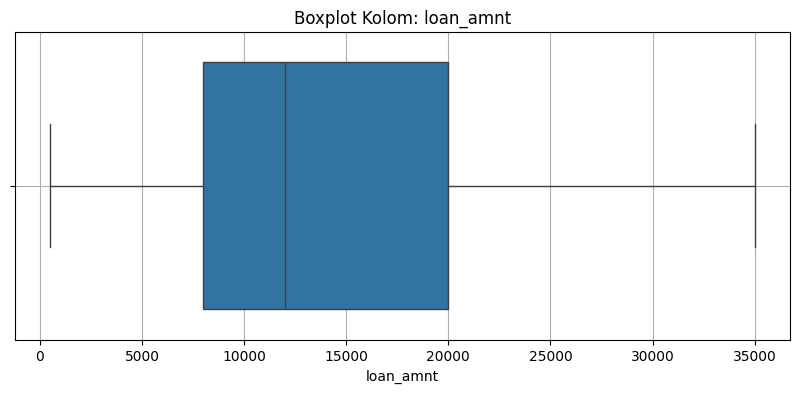

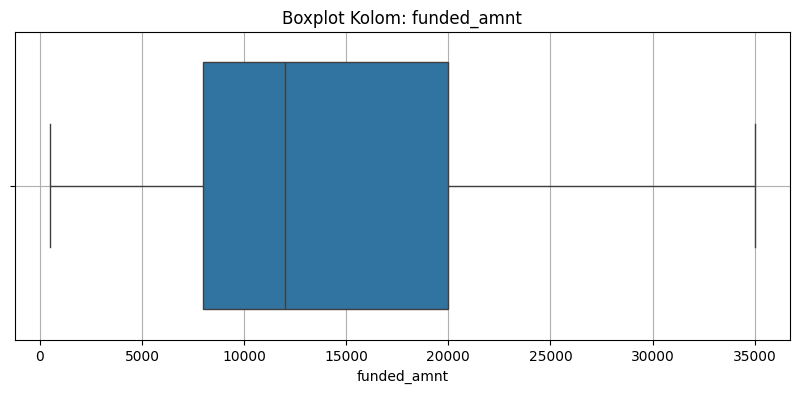

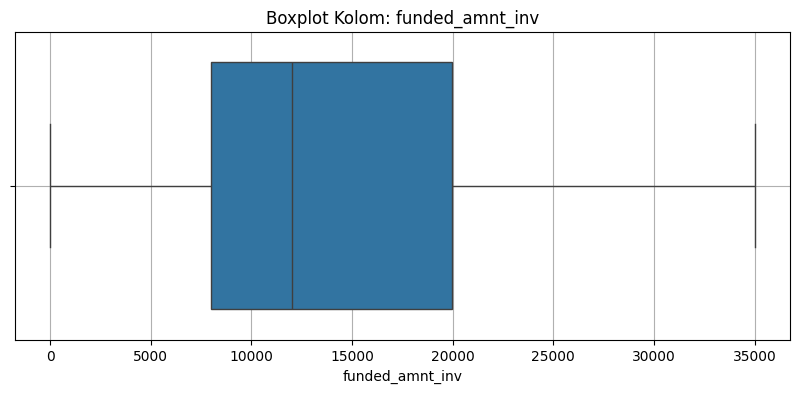

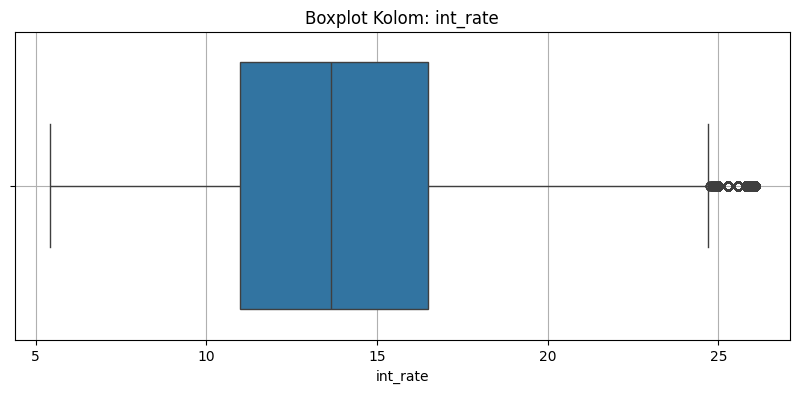

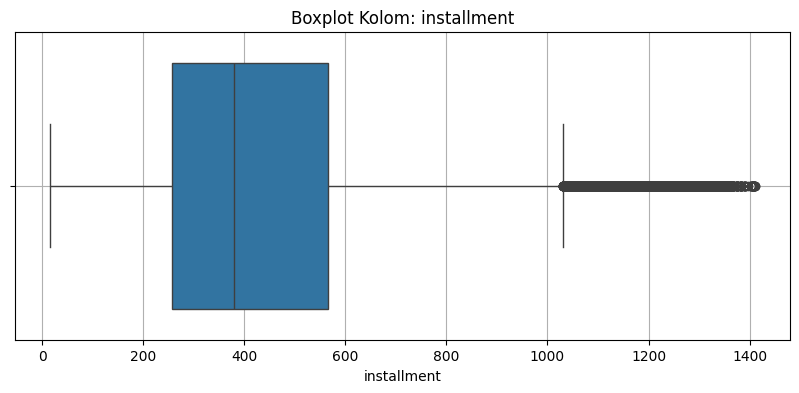

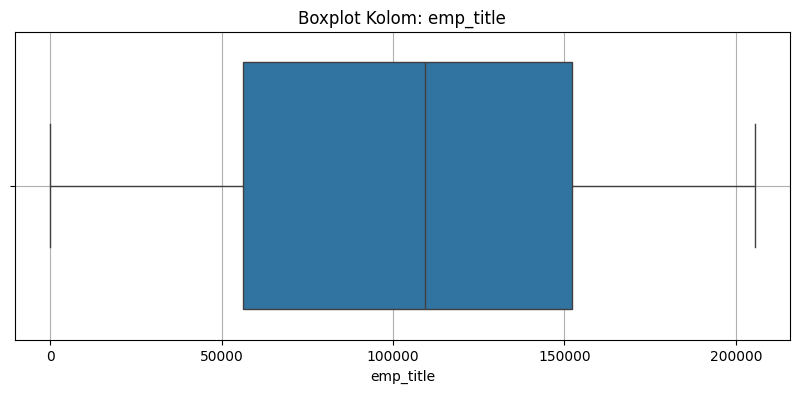

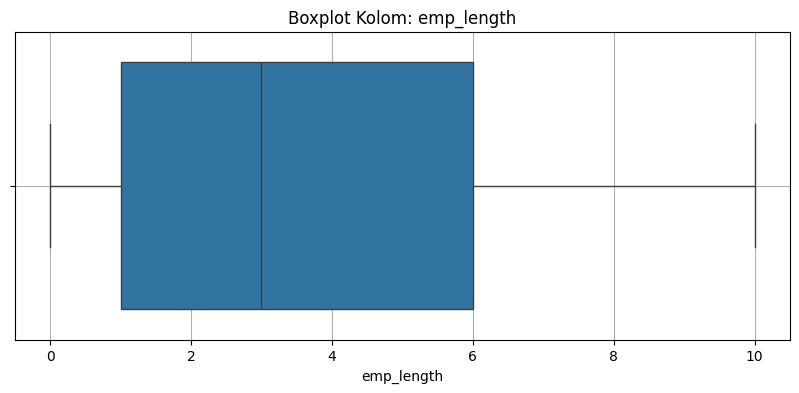

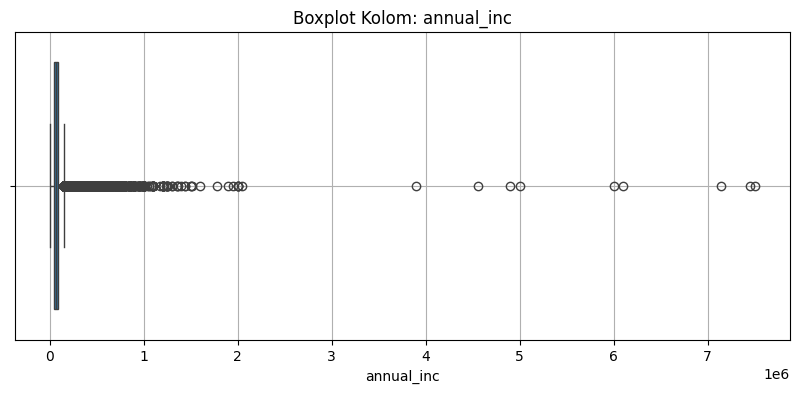

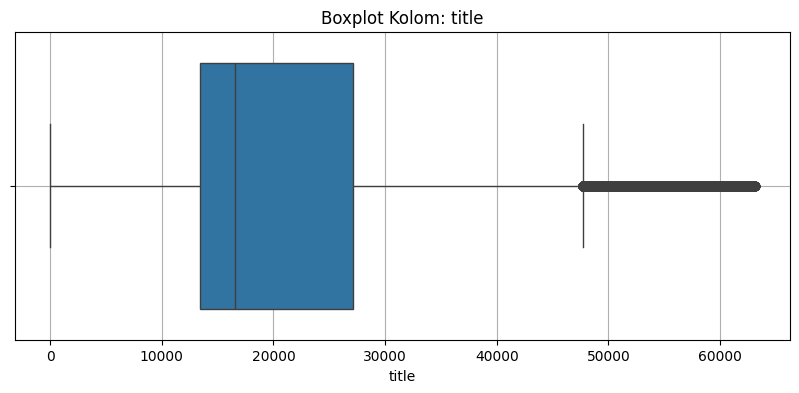

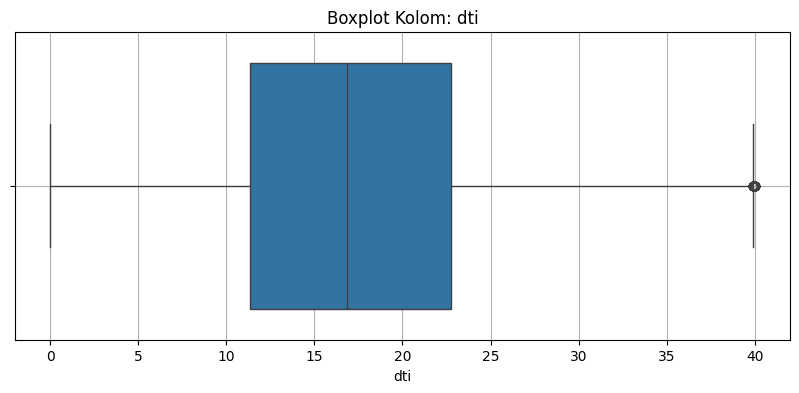

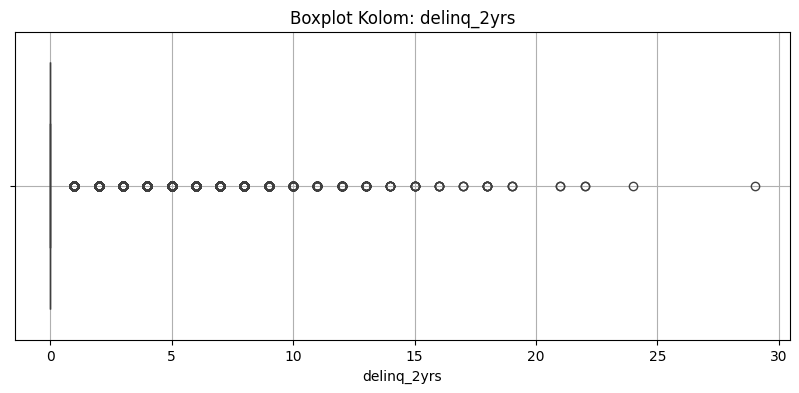

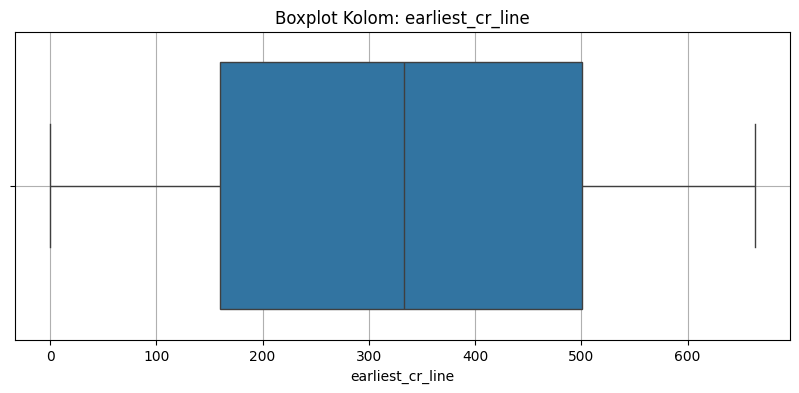

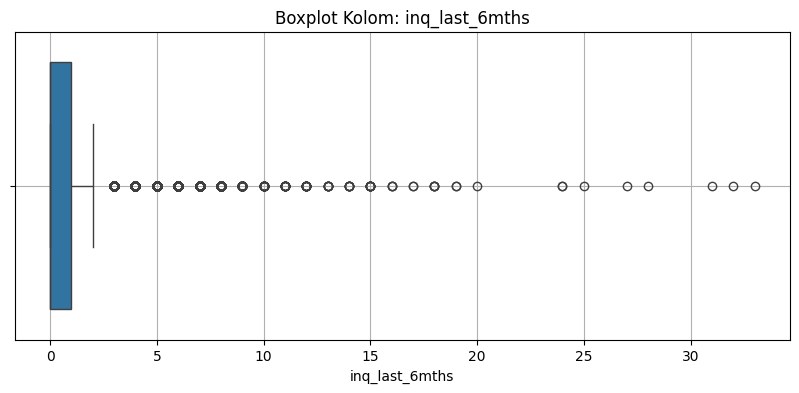

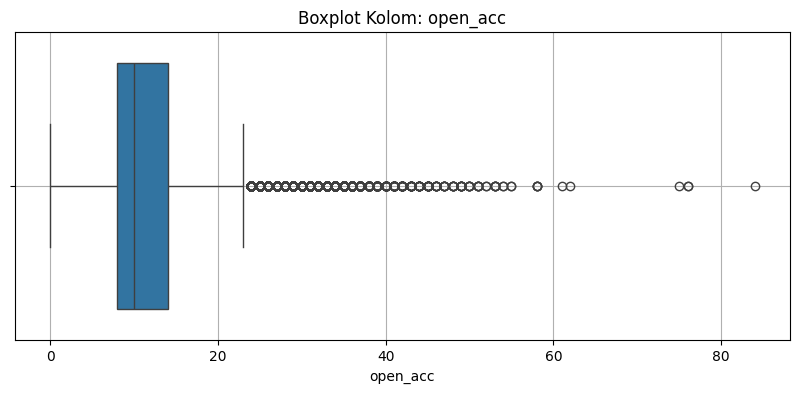

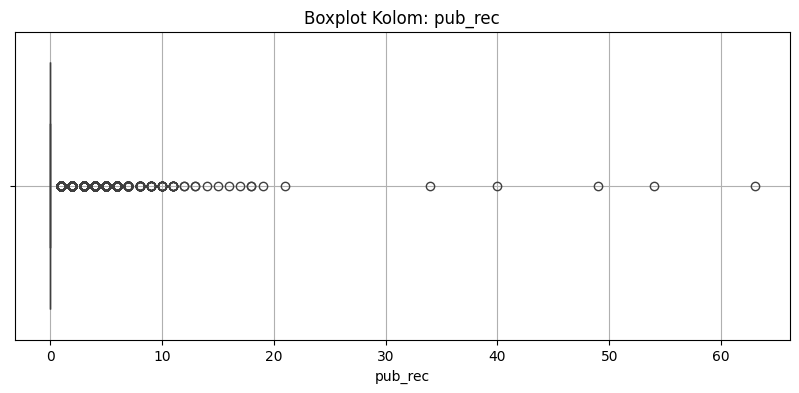

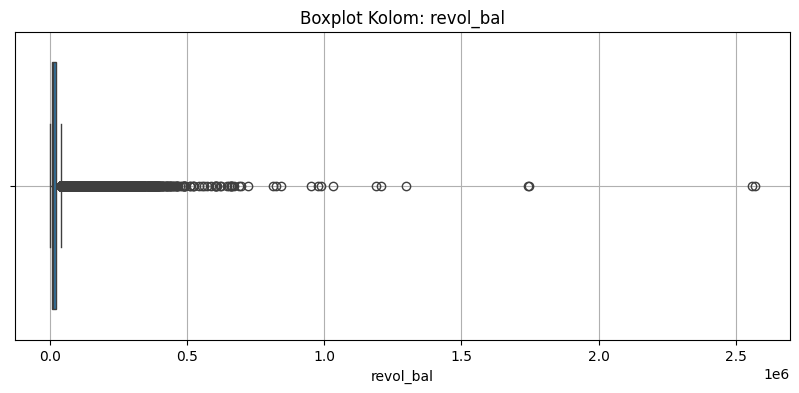

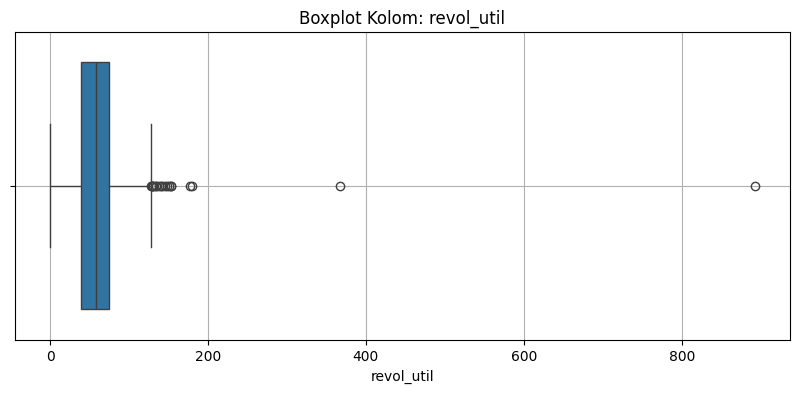

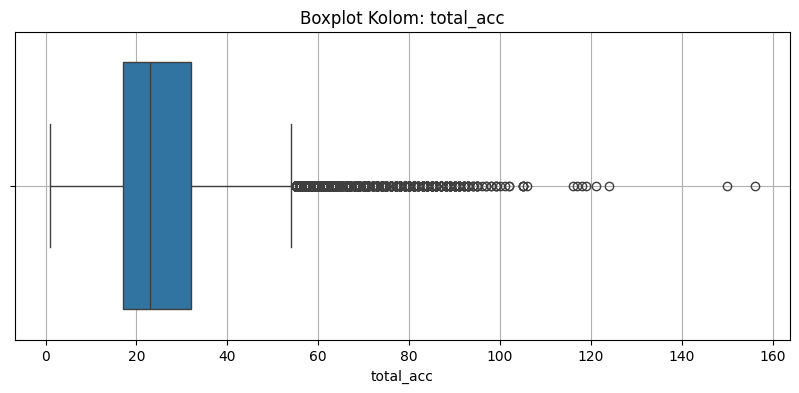

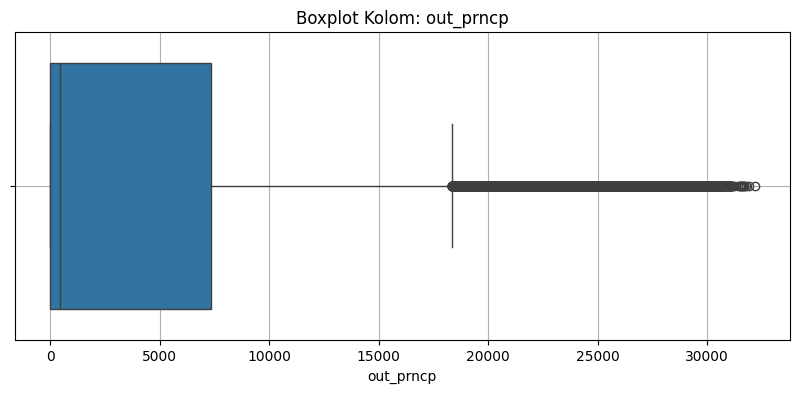

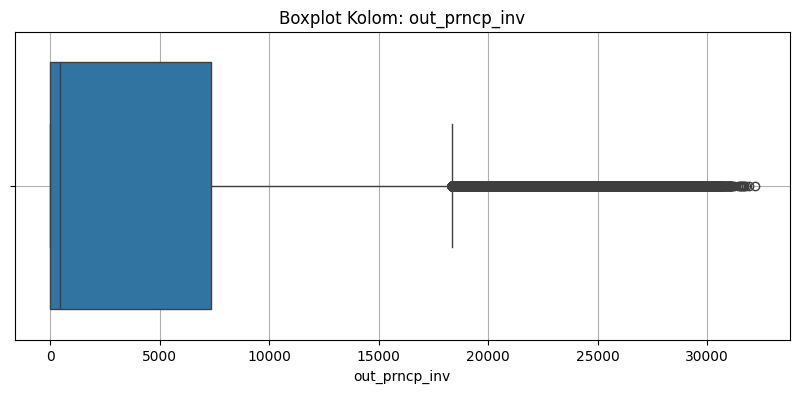

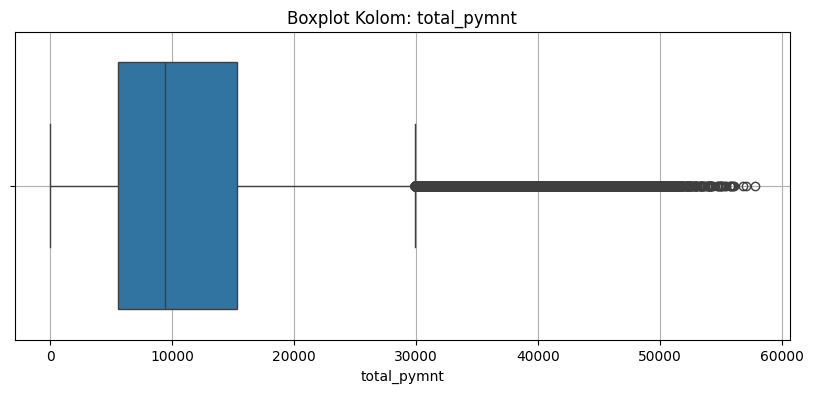

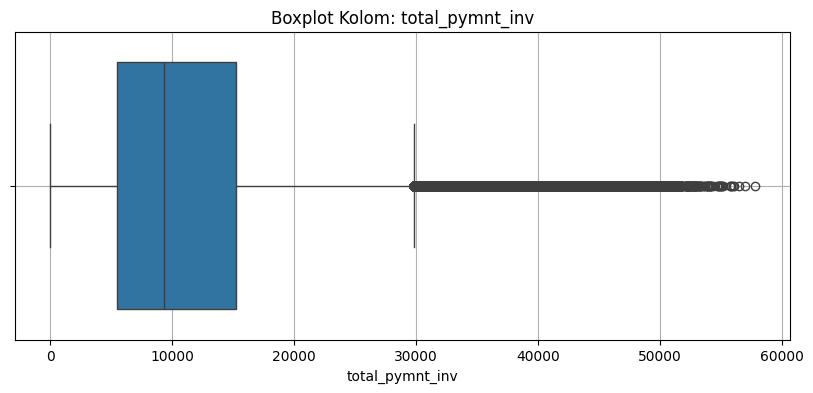

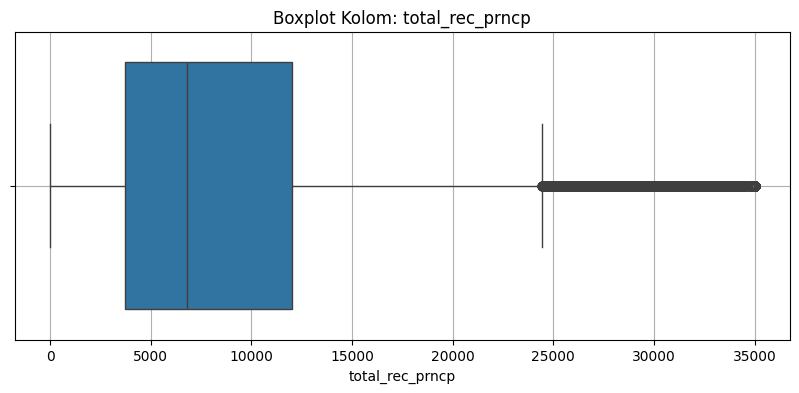

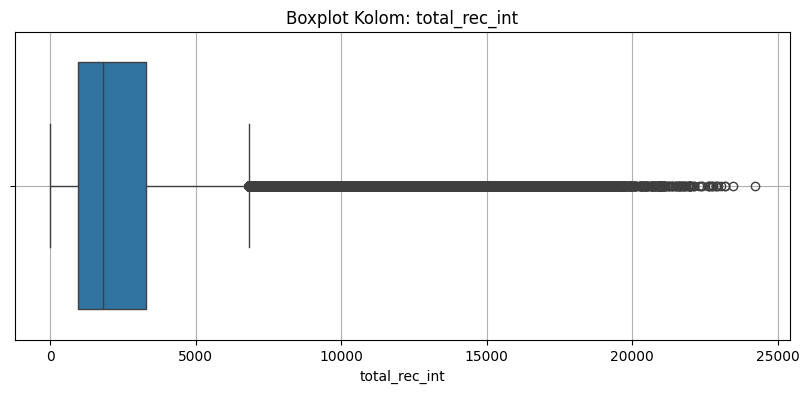

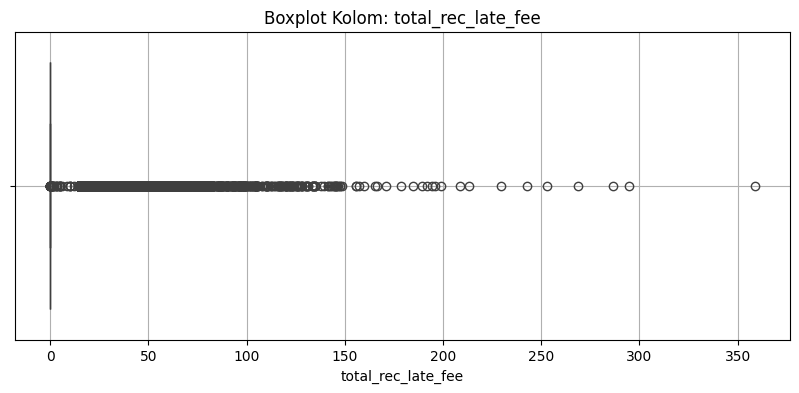

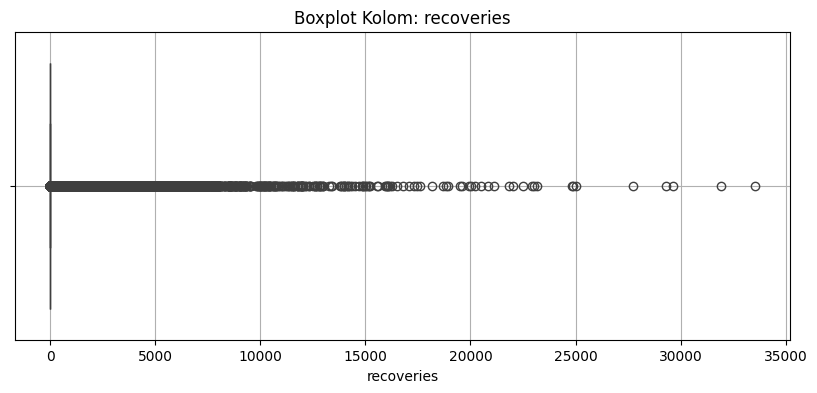

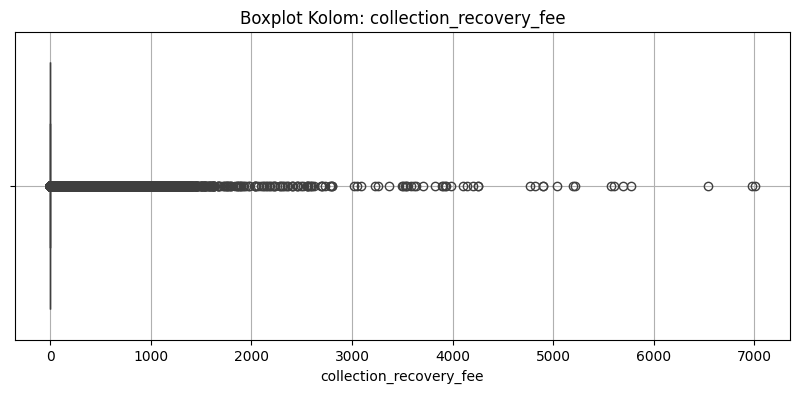

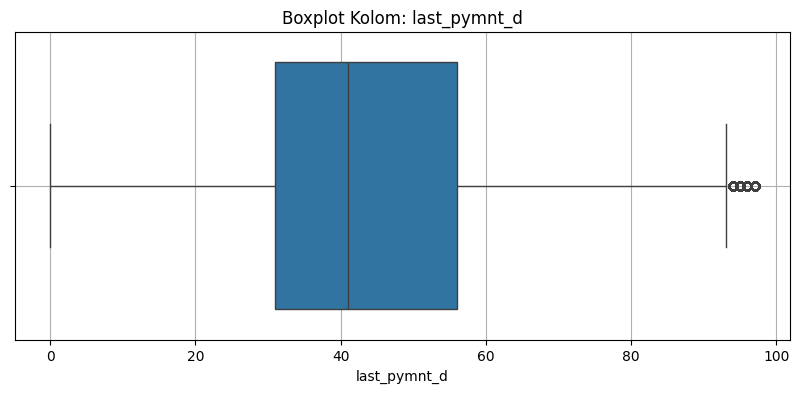

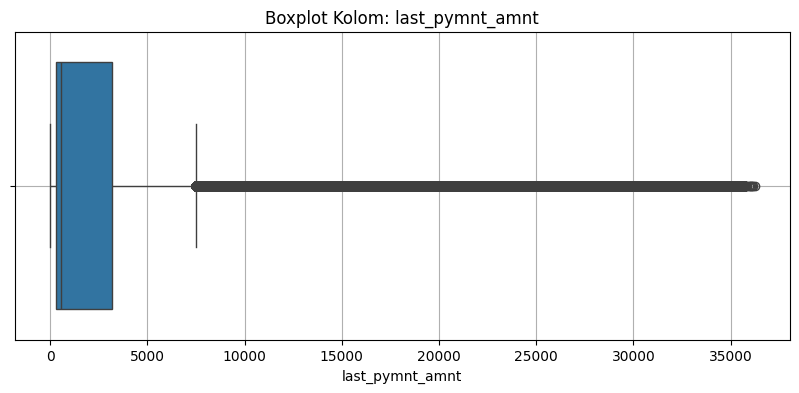

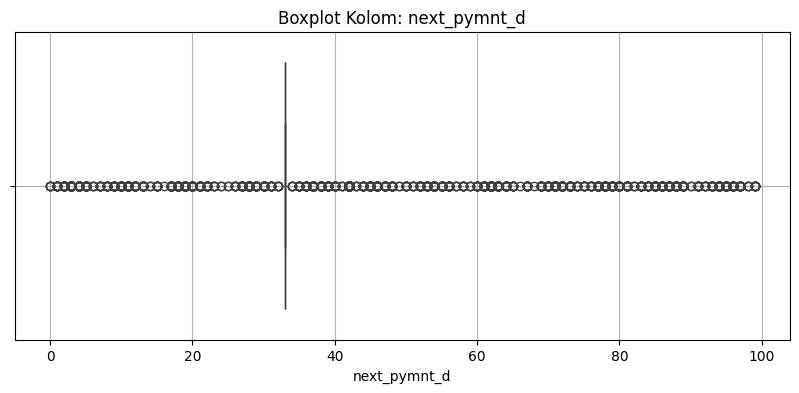

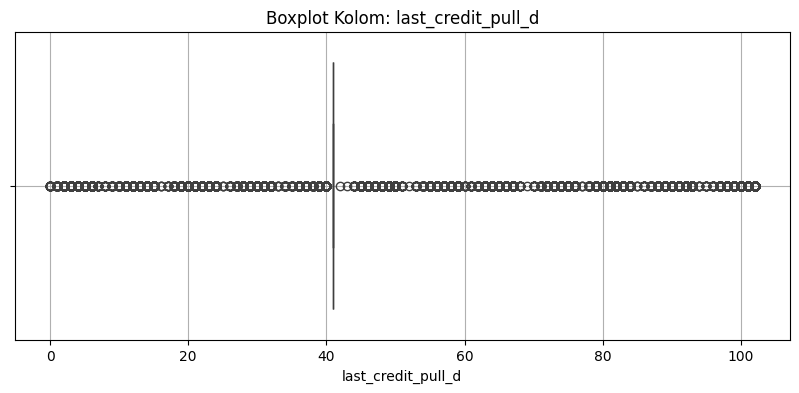

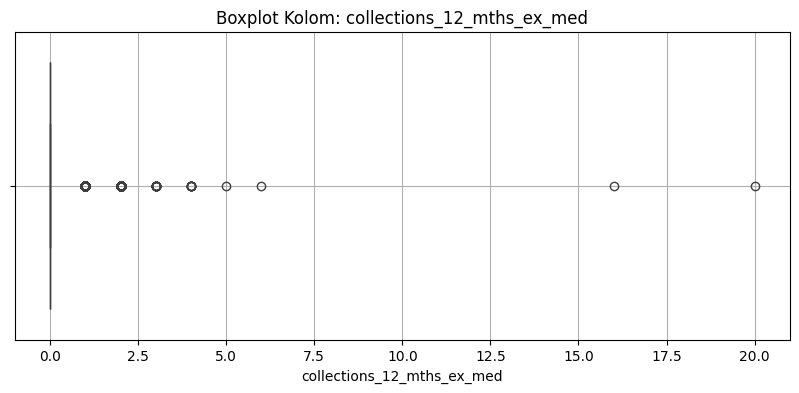

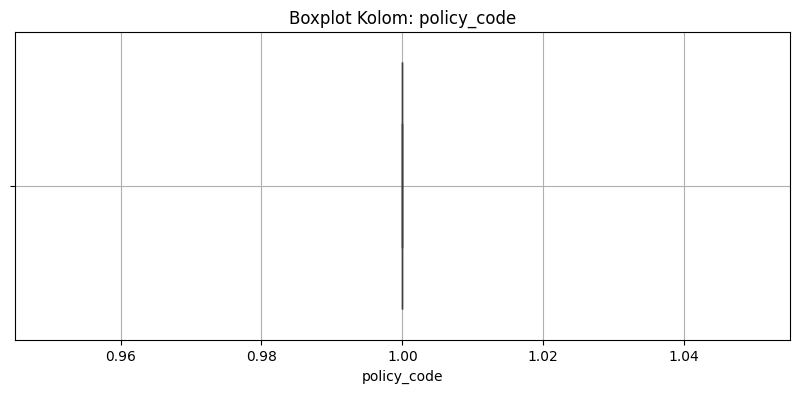

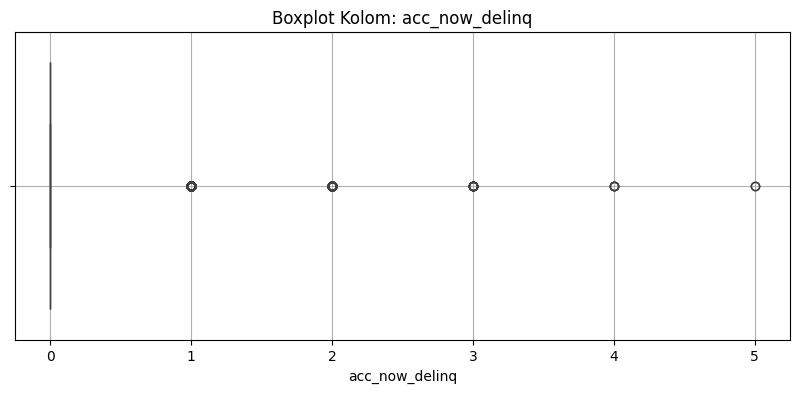

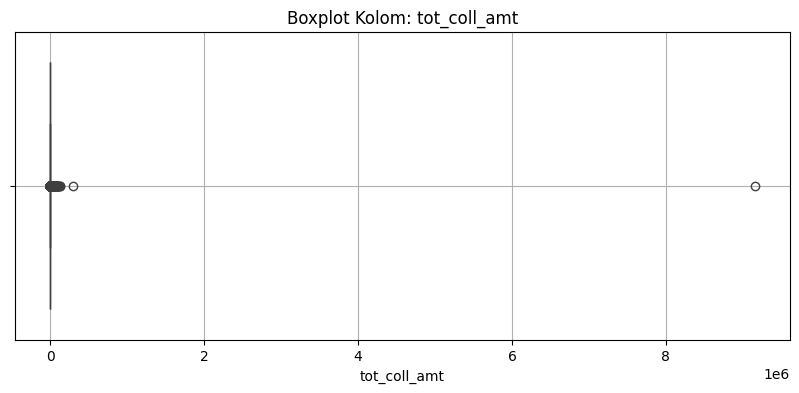

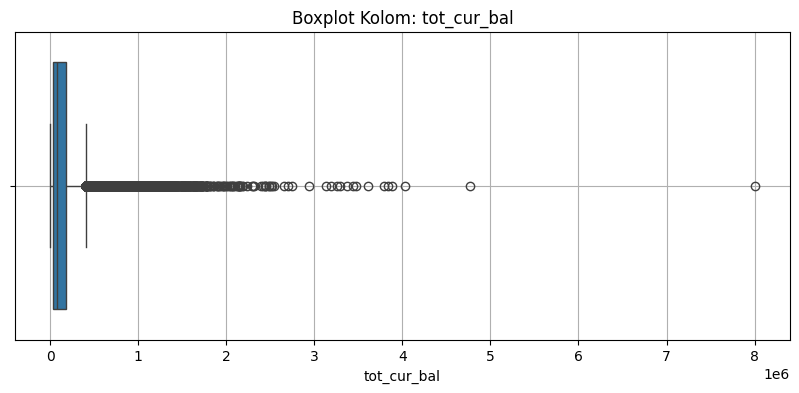

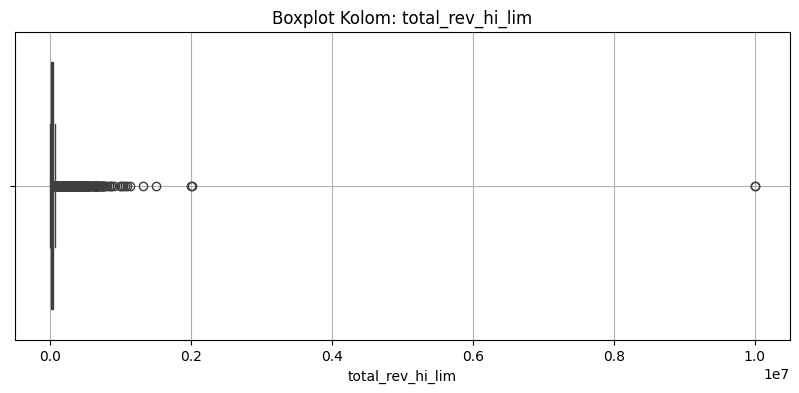

In [ ]:
for column in dnum_df.columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=dnum_df[column])
    plt.title(f'Boxplot Kolom: {column}')
    plt.xlabel(column)
    plt.grid(True)
    plt.show()


<b> Insight </b>
- Terdapat beberapa outlier namun, outlier pada dataset ini tidak dihapus karena sebagian besar nilai ekstrem yang terdeteksi mencerminkan kondisi nyata dalam data peminjaman, seperti pendapatan sangat tinggi, pembayaran terakhir yang besar, atau rasio utang yang tidak biasa. Menghapus outlier berpotensi menghilangkan kasus penting yang jarang terjadi namun relevan, sehingga model risiko kredit dapat kehilangan kemampuan mendeteksi peminjam berisiko tinggi

Melakukan encoding pada data kategorikal

In [ ]:
ecat_df = dcat_df.copy()

label_encoders = {}
for column in ecat_df.columns:
    if ecat_df[column].dtype == 'object' or str(ecat_df[column].dtype) == 'category':
        le = LabelEncoder()
        ecat_df[column] = le.fit_transform(ecat_df[column].astype(str))
        label_encoders[column] = le

ecat_df.head()

,term,grade,sub_grade,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,purpose,addr_state,initial_list_status,credit_risk
0,0,1,6,5,2,19,5,0,1,3,0,1
1,1,2,13,5,1,19,0,0,0,10,0,0
2,0,2,14,5,0,19,5,0,11,14,0,1
3,0,2,10,5,1,19,5,0,9,4,0,1
4,1,1,9,5,1,19,1,0,9,36,0,1


Menggabungkan data numerik dan kategori yang telah diproses

In [ ]:
combined_df = pd.concat([ecat_df, dnum_df], axis=1)
combined_df.head()

,term,grade,sub_grade,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,purpose,addr_state,...,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,policy_code,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,0,1,6,5,2,19,5,0,1,3,...,40.0,171.62,33.0,41.0,0.0,1,0.0,0.0,81539.0,22800.0
1,1,2,13,5,1,19,0,0,0,10,...,5.0,119.66,33.0,100.0,0.0,1,0.0,0.0,81539.0,22800.0
2,0,2,14,5,0,19,5,0,11,14,...,56.0,649.91,33.0,41.0,0.0,1,0.0,0.0,81539.0,22800.0
3,0,2,10,5,1,19,5,0,9,4,...,40.0,357.48,33.0,40.0,0.0,1,0.0,0.0,81539.0,22800.0
4,1,1,9,5,1,19,1,0,9,36,...,41.0,67.79,33.0,41.0,0.0,1,0.0,0.0,81539.0,22800.0


Melakukan standarisasi pada data

In [ ]:
scom_df = combined_df.copy()

scaler = StandardScaler()
snum = scaler.fit_transform(scom_df)
scom_df = pd.DataFrame(snum, columns=combined_df.columns, index=combined_df.index)

scom_df.head()

,term,grade,sub_grade,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,purpose,addr_state,...,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,policy_code,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,-0.616225,-0.618831,-0.775660,1.096523,1.164122,-1.154127,1.077960,-0.004393,-0.688465,-1.324904,...,-0.224267,-0.531492,-0.190459,-0.216636,-0.083608,0.0,-0.058307,-0.012089,-0.343273,-0.186939
1,1.622784,0.138524,0.296334,1.096523,-0.051674,-1.154127,-1.229824,-0.004393,-1.103049,-0.851352,...,-1.786709,-0.540846,-0.190459,3.086120,-0.083608,0.0,-0.058307,-0.012089,-0.343273,-0.186939
2,-0.616225,0.138524,0.449476,1.096523,-1.267470,-1.154127,1.077960,-0.004393,3.457374,-0.580752,...,0.489992,-0.445387,-0.190459,-0.216636,-0.083608,0.0,-0.058307,-0.012089,-0.343273,-0.186939
3,-0.616225,0.138524,-0.163092,1.096523,-0.051674,-1.154127,1.077960,-0.004393,2.628206,-1.257254,...,-0.224267,-0.498032,-0.190459,-0.272615,-0.083608,0.0,-0.058307,-0.012089,-0.343273,-0.186939
4,1.622784,-0.618831,-0.316234,1.096523,-0.051674,-1.154127,-0.768267,-0.004393,2.628206,0.907552,...,-0.179626,-0.550184,-0.190459,-0.216636,-0.083608,0.0,-0.058307,-0.012089,-0.343273,-0.186939


Membagi data menggunakan Train test split dengan rasio 0.2:1

In [ ]:
X = scom_df.drop(columns=['credit_risk'])
y = scom_df['credit_risk']
y = scom_df['credit_risk'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Modelling

Membangun dan melatih model Logistic Regression

In [ ]:
logReg = LogisticRegression(max_iter=1000, random_state=42)
logReg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Mengecek kinerja model Logistic Regression pada train data

In [ ]:
y_train_pred_lr = logReg.predict(X_train)

accuracy_train_lr = accuracy_score(y_train, y_train_pred_lr)
print("Evaluasi Model Klasifikasi Logistic Regression (Data Latih)")
print(f'Accuracy: {accuracy_train_lr:.4f}')
print("Classification Report:")
print(classification_report(y_train, y_train_pred_lr))

Evaluasi Model Klasifikasi Logistic Regression (Data Latih)
Accuracy: 0.9554
Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.89      0.92    109312
           0       0.96      0.98      0.97    263716

    accuracy                           0.96    373028
   macro avg       0.95      0.94      0.95    373028
weighted avg       0.96      0.96      0.95    373028



<b> Insight </b>
- Model Logistic Regression menunjukkan akurasi yang tinggi sebesar 95,54%, menandakan bahwa model mampu memprediksi status risiko kredit dengan baik pada data latih.

- Untuk kelas 0 (risiko baik), model memiliki precision sebesar 96% dan recall sebesar 98%, yang berarti sebagian besar peminjam berisiko baik berhasil diprediksi dengan benar, dengan kesalahan klasifikasi yang sangat kecil.

- Untuk kelas -1 (risiko buruk), model memiliki precision 95% dan recall 89%, artinya masih ada sebagian peminjam berisiko buruk yang salah diklasifikasikan sebagai risiko baik.

- Secara keseluruhan, nilai f1-score rata-rata tertimbang (weighted avg) sebesar 95% menunjukkan keseimbangan yang baik antara precision dan recall pada kedua kelas.

- Meski performa model sangat baik, ada sedikit potensi under-detection pada peminjam berisiko buruk (-1), yang bisa menjadi fokus perbaikan agar model lebih sensitif terhadap kelompok berisiko tinggi.

Mencoba untuk menyesuaikan parameter model Logistic Regression menggunakan grid search

In [ ]:
paramGrid_lr = {
    'penalty': ['l1'],
    'C': [0.1, 1],
    'solver': ['liblinear'],
    'max_iter': [5, 8]
}

gridSearch_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    paramGrid_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

gridSearch_lr.fit(X_train, y_train)

print("Best Parameters for Logistic Regression (Fast Search):", gridSearch_lr.best_params_)

Best Parameters for Logistic Regression (Fast Search): {'C': 0.1, 'max_iter': 8, 'penalty': 'l1', 'solver': 'liblinear'}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Mengecek performa model Logistic Regression setelah tuning

In [ ]:
best_lr = gridSearch_lr.best_estimator_

y_train_pred_dt = best_lr.predict(X_train)

accuracy_train_dt = accuracy_score(y_train, y_train_pred_dt)
print("Evaluasi Model Klasifikasi Logistic Regression (Data Latih)")
print(f'Accuracy: {accuracy_train_dt:.4f}')
print("Classification Report:")
print(classification_report(y_train, y_train_pred_dt))

Evaluasi Model Klasifikasi Logistic Regression (Data Latih)
Accuracy: 0.9484
Classification Report:
              precision    recall  f1-score   support

          -1       0.96      0.86      0.91    109312
           0       0.94      0.99      0.96    263716

    accuracy                           0.95    373028
   macro avg       0.95      0.92      0.94    373028
weighted avg       0.95      0.95      0.95    373028



<b> Insight </b>
- Hasil tuning pada model Logistic Regression menunjukkan akurasi sebesar 94,84%, sedikit lebih rendah dibandingkan model awal. Walaupun performa pada kelas peminjam berisiko baik (kelas 0) tetap tinggi dengan recall mencapai 99%, kemampuan model dalam mengenali peminjam berisiko buruk (-1) menurun dengan recall hanya 86%. Hal ini menunjukkan bahwa hasil tuning tidak memberikan peningkatan signifikan dan justru menurunkan performa pada sebagian kelas target. Oleh karena itu, pada tahap pengujian menggunakan data uji, model Logistic Regression awal dipilih karena memberikan kinerja yang lebih stabil dan seimbang dalam memprediksi risiko kredit

Membangun dan melatih model Decision Tree

In [ ]:
decTree = DecisionTreeClassifier(
    random_state=42,
    max_depth=2,
    min_samples_split=25,
    min_samples_leaf=15
)
decTree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=15, min_samples_split=25,
                       random_state=42)

Mengecek kinerja model Decision Tree Regression pada train data

In [ ]:
y_train_pred_dt = decTree.predict(X_train)

accuracy_train_dt = accuracy_score(y_train, y_train_pred_dt)
print("Evaluasi Model Klasifikasi Decision Tree (Data Latih)")
print(f'Accuracy: {accuracy_train_dt:.4f}')
print("Classification Report:")
print(classification_report(y_train, y_train_pred_dt))

Evaluasi Model Klasifikasi Decision Tree (Data Latih)
Accuracy: 0.9187
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.72      0.84    109312
           0       0.90      1.00      0.95    263716

    accuracy                           0.92    373028
   macro avg       0.95      0.86      0.89    373028
weighted avg       0.93      0.92      0.91    373028



<b> Insight </b>
- Model Decision Tree mencapai akurasi sebesar 91,87%, menunjukkan kinerja yang cukup baik dalam mengklasifikasikan risiko kredit pada data latih

- Pada kelas 0 (risiko baik), model menunjukkan precision sebesar 90% dan recall mencapai 100%, yang berarti hampir semua peminjam berisiko baik berhasil dikenali tanpa ada yang terlewat

- Namun, pada kelas -1 (risiko buruk), meskipun precision mencapai 100%, recall hanya 72%, yang berarti banyak peminjam berisiko buruk tidak terdeteksi dengan baik dan salah diklasifikasikan sebagai berisiko baik

- Nilai f1-score rata-rata tertimbang (weighted avg) sebesar 91% mengindikasikan performa keseluruhan yang baik, namun ketidakseimbangan recall antar kelas menunjukkan bahwa model Decision Tree cenderung lebih fokus pada pengenalan peminjam berisiko baik dan kurang sensitif terhadap peminjam berisiko buruk

- Hal ini dapat meningkatkan risiko kelolosan peminjam dengan potensi gagal bayar, sehingga perlu dilakukan penyetelan parameter atau teknik lain seperti penyeimbangan data untuk meningkatkan kemampuan deteksi risiko buruk

Mencoba untuk menyesuaikan parameter model Decision Tree menggunakan grid search

In [ ]:
paramGrid_dt = {
    'max_depth': [None, 4, 6],
    'min_samples_split': [20, 25],
    'min_samples_leaf': [14, 18],
    'criterion': ['gini', 'entropy']
}

gridSearch_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              paramGrid_dt,
                              cv=5,
                              scoring='accuracy',
                              n_jobs=-1)

gridSearch_dt.fit(X_train, y_train)

print("Best Parameters for Decision Tree:", gridSearch_dt.best_params_)

Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 18, 'min_samples_split': 20}


Mengecek performa model Decision Tree setelah tuning

In [ ]:
best_dt = gridSearch_dt.best_estimator_

y_train_pred_dt = best_dt.predict(X_train)

accuracy_train_dt = accuracy_score(y_train, y_train_pred_dt)
print("Evaluasi Model Klasifikasi Decision Tree (Data Latih)")
print(f'Accuracy: {accuracy_train_dt:.4f}')
print("Classification Report:")
print(classification_report(y_train, y_train_pred_dt))

Evaluasi Model Klasifikasi Decision Tree (Data Latih)
Accuracy: 0.9999
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00    109312
           0       1.00      1.00      1.00    263716

    accuracy                           1.00    373028
   macro avg       1.00      1.00      1.00    373028
weighted avg       1.00      1.00      1.00    373028



<b> Insight </b>
- Hasil tuning pada model Decision Tree menunjukkan akurasi hampir sempurna sebesar 99,99% pada data latih dengan precision, recall, dan f1-score yang semuanya mencapai 1.00. Meskipun sekilas terlihat sangat baik, performa yang terlalu tinggi ini merupakan indikasi overfitting, di mana model terlalu menyesuaikan diri dengan data latih sehingga berpotensi gagal melakukan generalisasi pada data baru. Oleh karena itu, untuk tahap evaluasi selanjutnya, digunakan model Decision Tree awal (sebelum tuning) yang memiliki performa lebih realistis dan diharapkan dapat memberikan hasil yang lebih seimbang pada data uji.

# Evaluation

Evaluasi kinerja model Logistic Regression pada test data

In [ ]:
# Memprediksi data uji
y_pred_lr = logReg.predict(X_test)

# Evaluasi model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Evaluasi Model Klasifikasi Logistic Regression")
print(f'Accuracy: {accuracy_lr:.4f}')
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Evaluasi Model Klasifikasi Logistic Regression
Accuracy: 0.9540
Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.89      0.92     27560
           0       0.96      0.98      0.97     65697

    accuracy                           0.95     93257
   macro avg       0.95      0.94      0.94     93257
weighted avg       0.95      0.95      0.95     93257



Evaluasi kinerja model Decition Tree pada test data

In [ ]:
# Memprediksi data uji
y_pred_dt = decTree.predict(X_test)

# Evaluasi model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Evaluasi Model Klasifikasi Decision Tree")
print(f'Accuracy: {accuracy_dt:.4f}')
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Evaluasi Model Klasifikasi Decision Tree
Accuracy: 0.9172
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.72      0.84     27560
           0       0.89      1.00      0.94     65697

    accuracy                           0.92     93257
   macro avg       0.95      0.86      0.89     93257
weighted avg       0.93      0.92      0.91     93257



<b> Insight </b>
- Logistic Regression menunjukkan performa sangat baik dengan akurasi mencapai 95,4% pada data uji. Model ini mampu menjaga keseimbangan prediksi di kedua kelas, terbukti dari nilai precision, recall, dan f1-score yang konsisten di sekitar 0,95. Hasil ini mencerminkan kemampuan generalisasi yang kuat tanpa indikasi overfitting berlebihan, sehingga Logistic Regression menjadi pilihan yang lebih andal untuk prediksi risiko kredit dalam dataset ini.

- Decision Tree mengalami penurunan performa dibandingkan akurasi sempurna pada data latih, dengan akurasi uji hanya 91,7%. Recall pada kelas -1 lebih rendah (0,80), menunjukkan model ini cenderung melewatkan prediksi pada pinjaman berisiko buruk. Meskipun Decision Tree lebih fleksibel dan mampu mempelajari pola kompleks, hasil ini mengonfirmasi bahwa model tersebut sebelumnya overfit dan kurang stabil saat diaplikasikan pada data baru.

# Conclusion

Sebagai kesimpulan, hasil evaluasi menunjukkan bahwa Logistic Regression lebih unggul dalam hal akurasi dan kemampuan generalisasi dibandingkan Decision Tree, yang terbukti overfit pada data latih dan kurang stabil pada data uji. Oleh karena itu, Logistic Regression lebih tepat dipilih sebagai model prediksi risiko kredit dalam kasus ini, karena mampu memberikan performa yang konsisten dan andal saat diterapkan pada data baru.